# Clustering Candidates Analysis

In [1]:
import os, sys
import polars as pl

pl.Config.set_fmt_str_lengths(5000)

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')

sys.path.append(project_path)

from src.utils.clustering_analysis_utils import (
    get_SampleDistClustering_results,
    get_KMeans_results
)

from config.config_07b import embeddings_cols_50, embeddings_cols_90

processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
processed_data_path = os.path.join(processed_data_dir, '06_processed_data.parquet')
processed_data = pl.read_parquet(processed_data_path)

In [2]:
QUANT_COMPARISON_COLS = [
    'political_stance_score', 
    'argument_quality_score', 
    'sentiment_score'
]

CAT_COMPARISON_COLS = [
    'discourse_tone_score_label', 
    'dominant_frame_score_label', 
    'argument_quality_score_label', 
    'sentiment_score_label', 
    'political_stance_score_label'
]

CAT_COMPARISON_ORDER = {
    'political_stance_score_label': [
        'Strongly Pro-Palestine',
        'Leaning Pro-Palestine',
        'Neutral / Balanced',
        'Leaning Pro-Israel',
        'Strongly Pro-Israel'
    ],
    'sentiment_score_label': [
        'Very Negative',
        'Moderately Negative',
        'Mildly Negative',
        'Neutral',
        'Mildly Positive',
        'Moderately Positive',
        'Very Positive',
    ],
    'argument_quality_score_label': [
        'Spam / Non-Argument',
        'Pure Reaction', 
        'Bare Opinion',
        'Justified Opinion',
        'Reasoned Argument',
        'Sophisticated Discourse'
    ]
}

ASSOCIATION_VAR_TYPES = {
    'sentiment_score': 'continuous',
    'political_stance_score': 'ordinal' ,
    'argument_quality_score': 'ordinal', 
    'discourse_tone_score': 'nominal', 
    'dominant_frame_score': 'nominal', 
}

N_CLUSTERS_LIST = range(2,6)


## Clustering I: Data - Discursive Scores

In [3]:
numerical_cols = [
    'sentiment_score'
]

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols + ordinal_cols
binary_cols = []
multiclass_cols = nominal_cols

SampleDistClustering-KMedoids-PAM - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


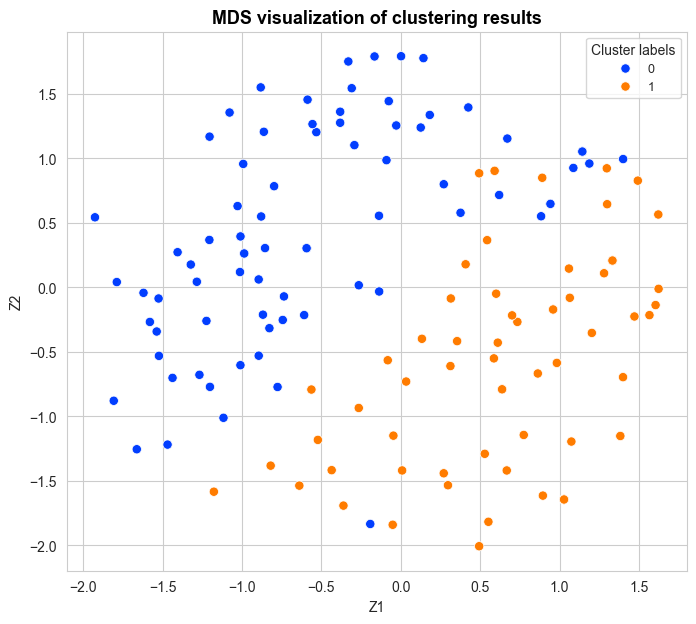

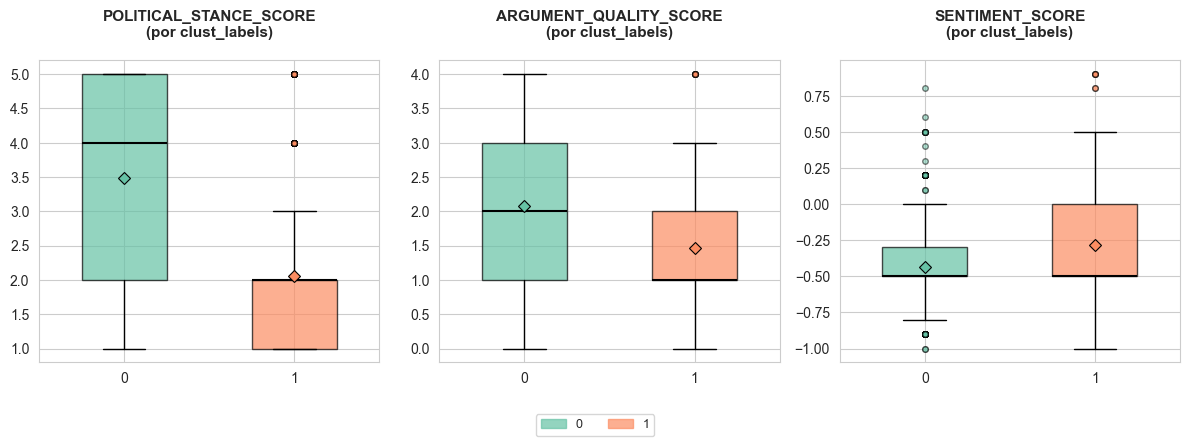

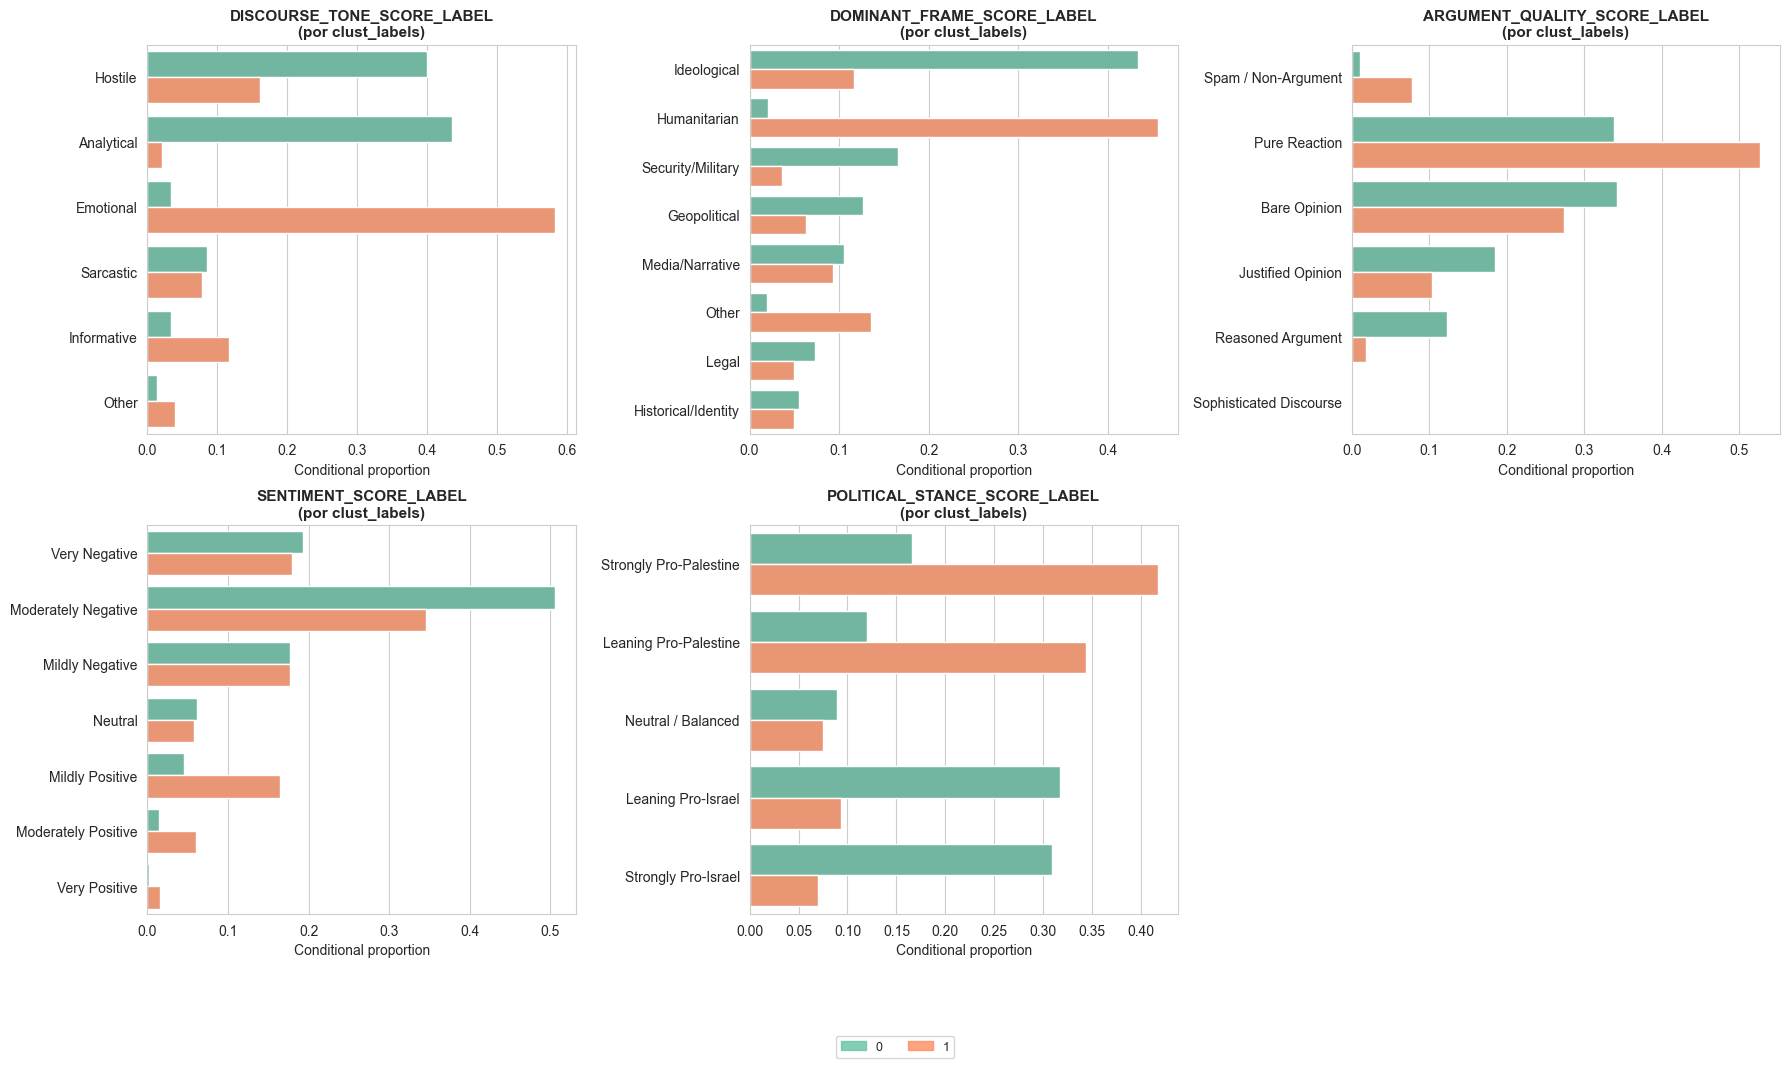

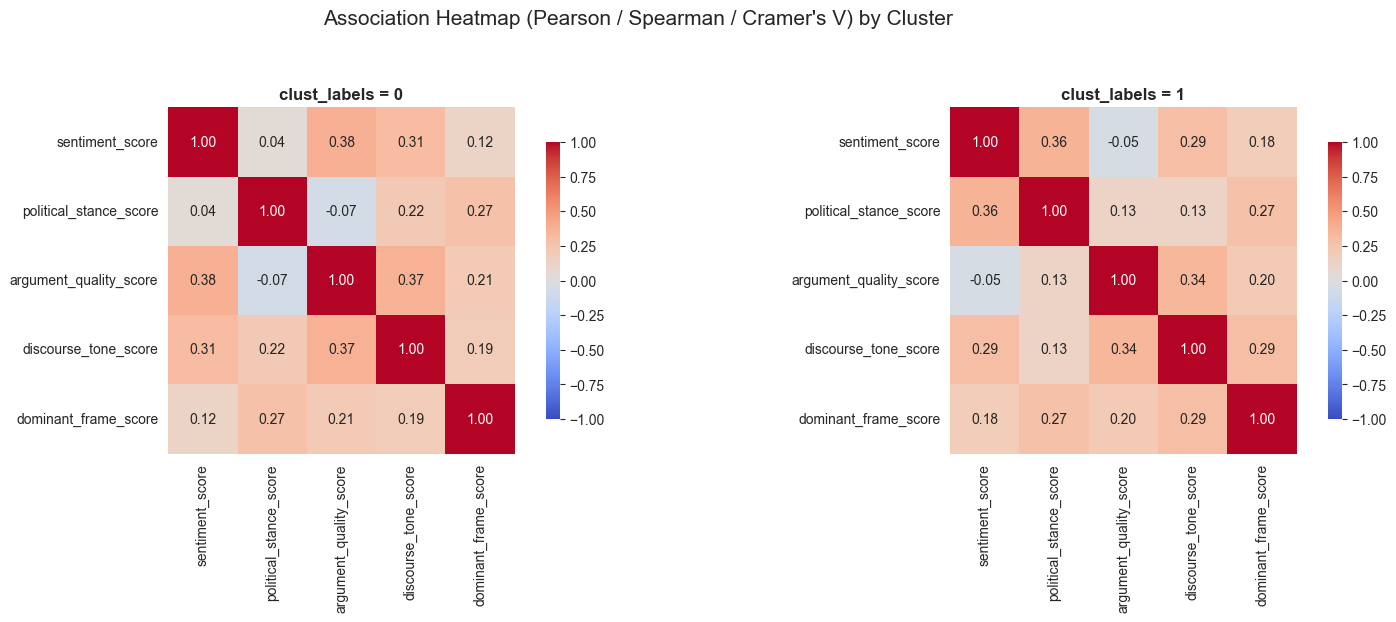

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------
shape: (11, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ post_title ┆ post_body  ┆ comment_bo ┆ discourse ┆ dominant_ ┆ argument_ ┆ sentiment ┆ political │
│ ---        ┆ ---        ┆ dy         ┆ _tone_sco ┆ frame_sco ┆ quality_s ┆ _score_la ┆ _stance_s │
│ str        ┆ str        ┆ ---        ┆ re_label  ┆ re_label  ┆ core_labe ┆ bel       ┆ core_labe │
│            ┆            ┆ str        ┆ ---       ┆ ---       ┆ l         ┆ ---       ┆ l         │
│            ┆            ┆            ┆ str       ┆ str       ┆ ---       ┆ str       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ str       ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Israel and ┆ Why are    ┆ I’m gonna  ┆ Ana

c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


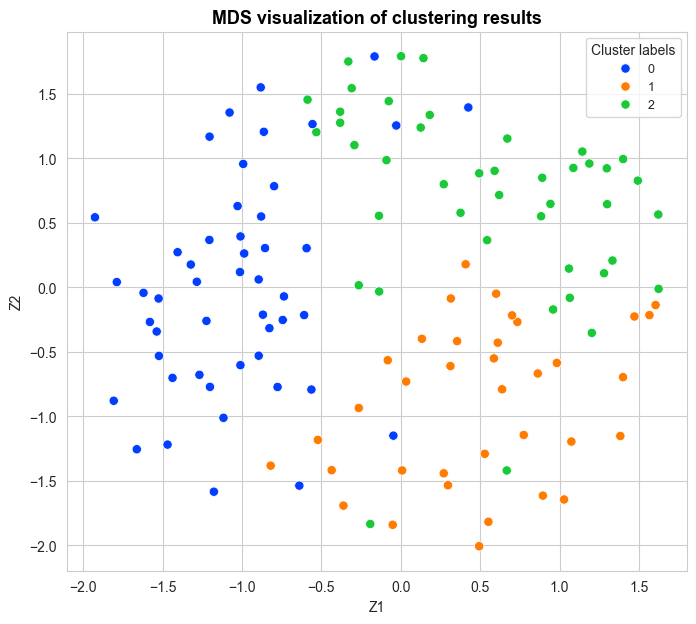

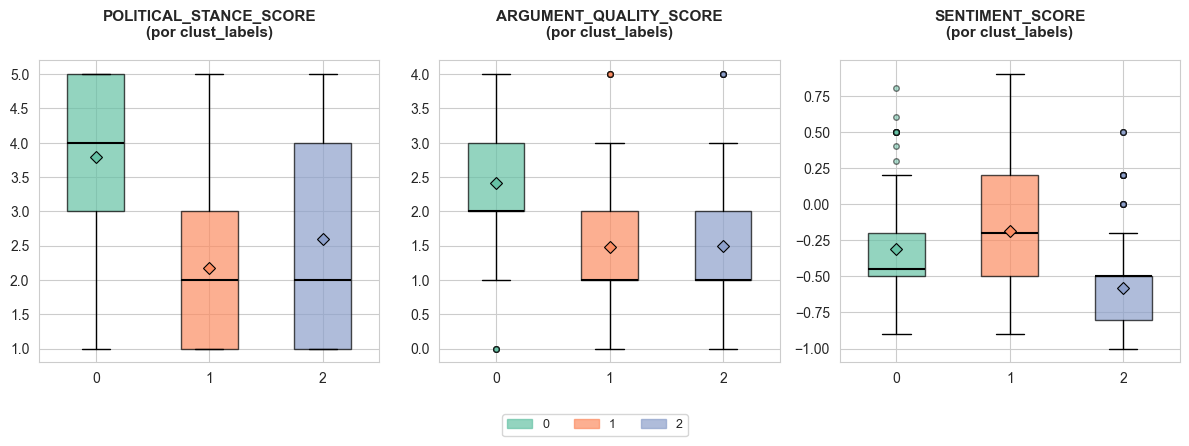

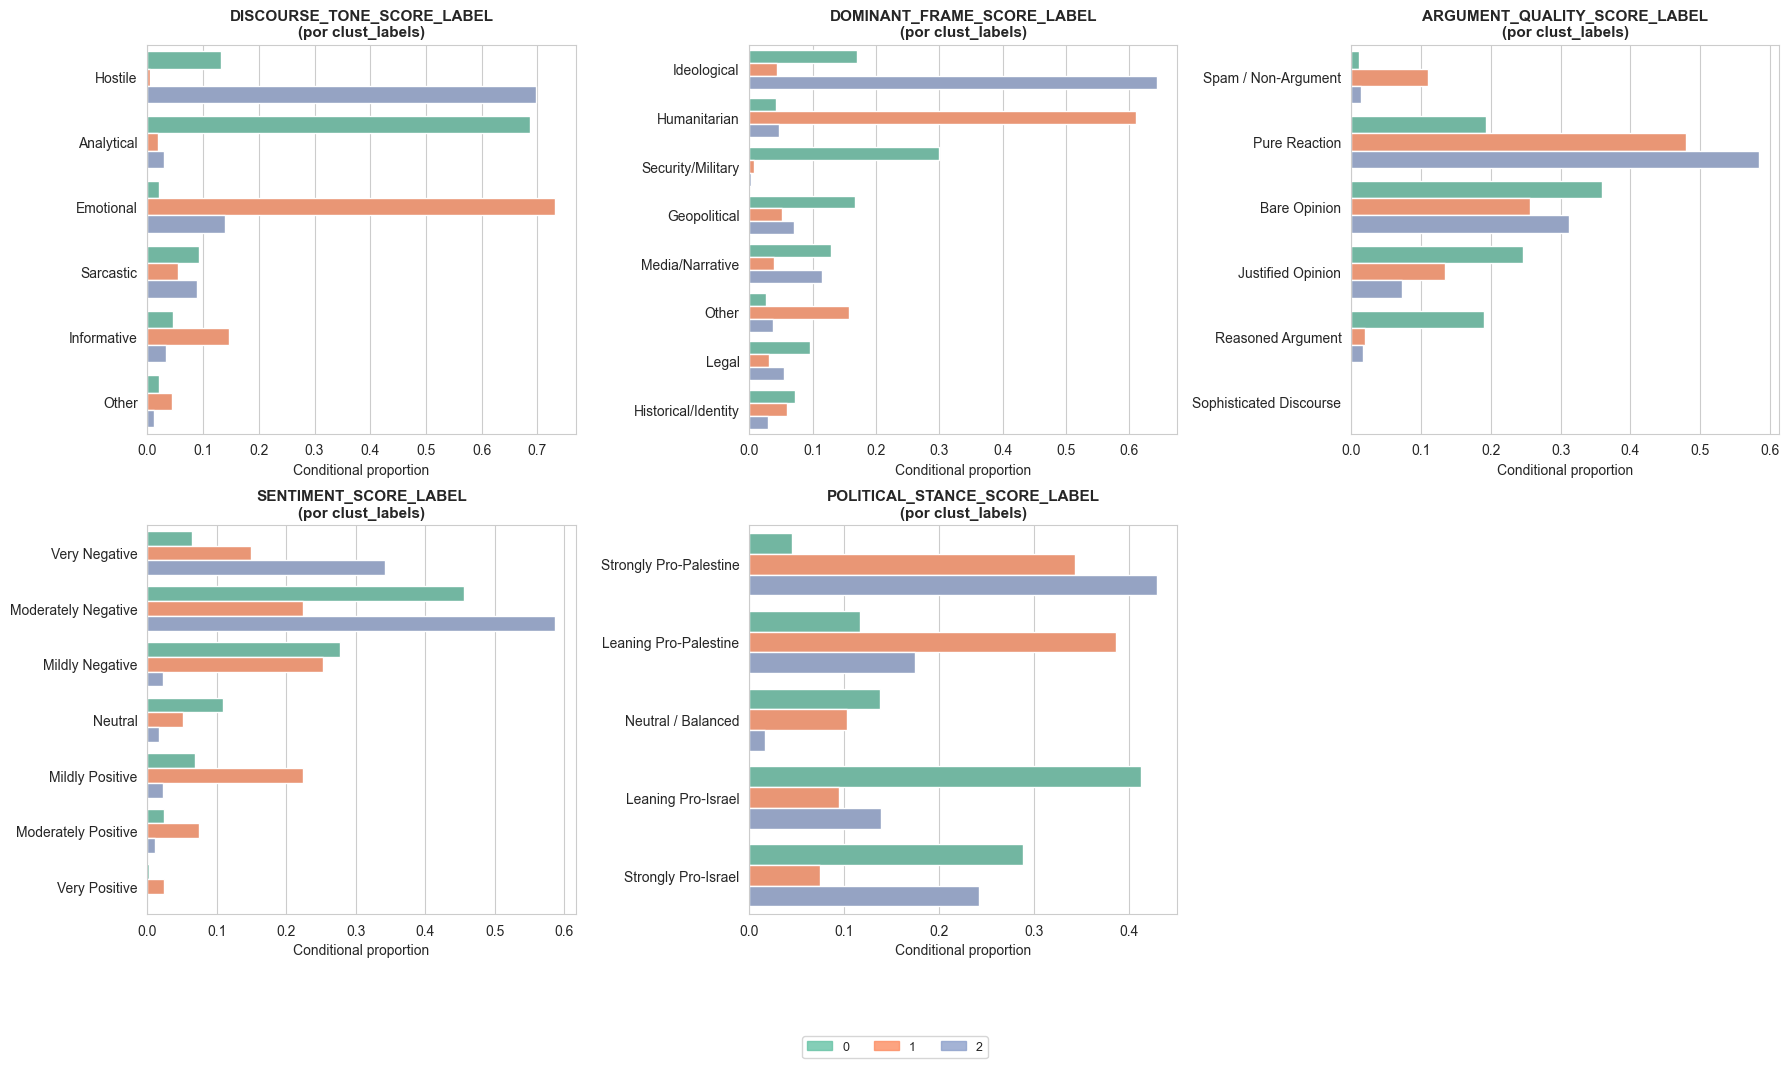

KeyboardInterrupt: 

In [9]:
for n_clusters in N_CLUSTERS_LIST:

    get_SampleDistClustering_results(
        n_clusters, processed_data[:1000], quant_cols, binary_cols, multiclass_cols, 
        QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
)

# Time: 30 mins

## Clustering II: Data - Discursive Scores + Embeddings

In [10]:
numerical_cols = ['sentiment_score'] + embeddings_cols_50

ordinal_cols = [
    'argument_quality_score',
    'political_stance_score',
]

nominal_cols = [
    'discourse_tone_score',
    'dominant_frame_score',
]


quant_cols = numerical_cols
binary_cols = []
multiclass_cols = nominal_cols + ordinal_cols

SampleDistClustering-KMedoids-PAM - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


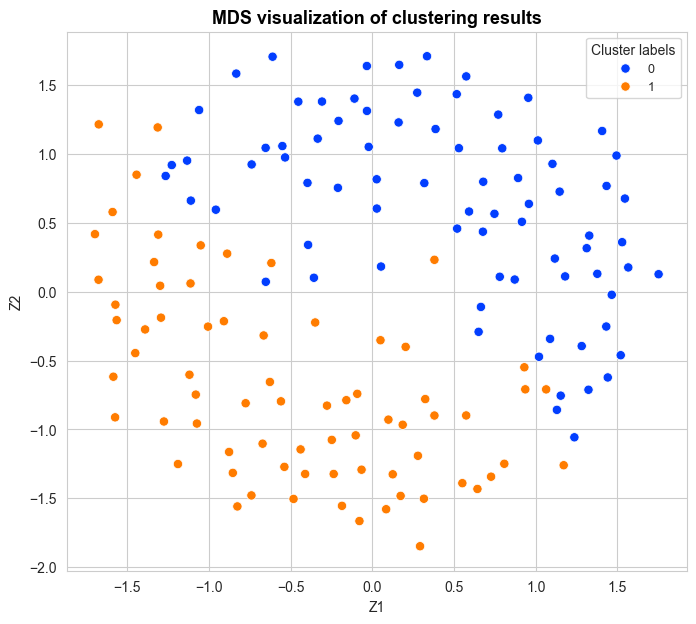

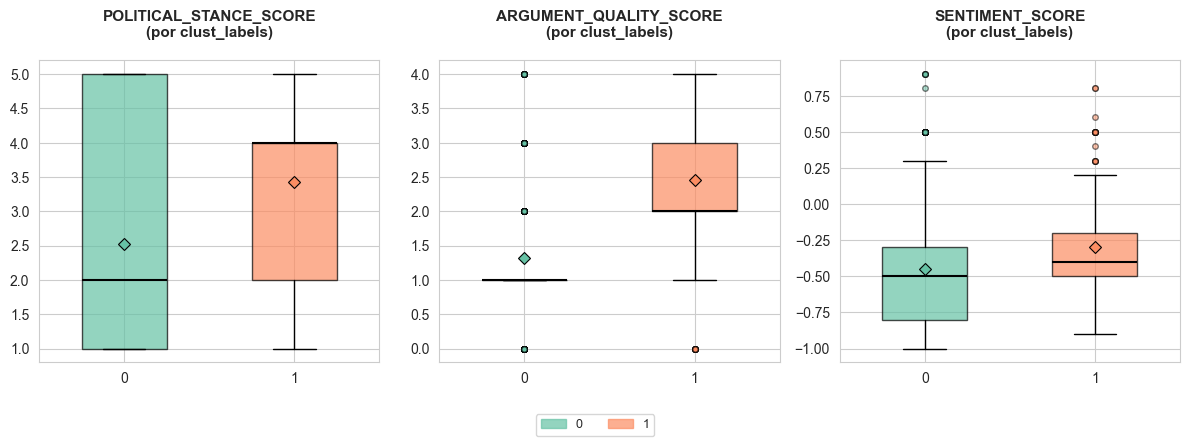

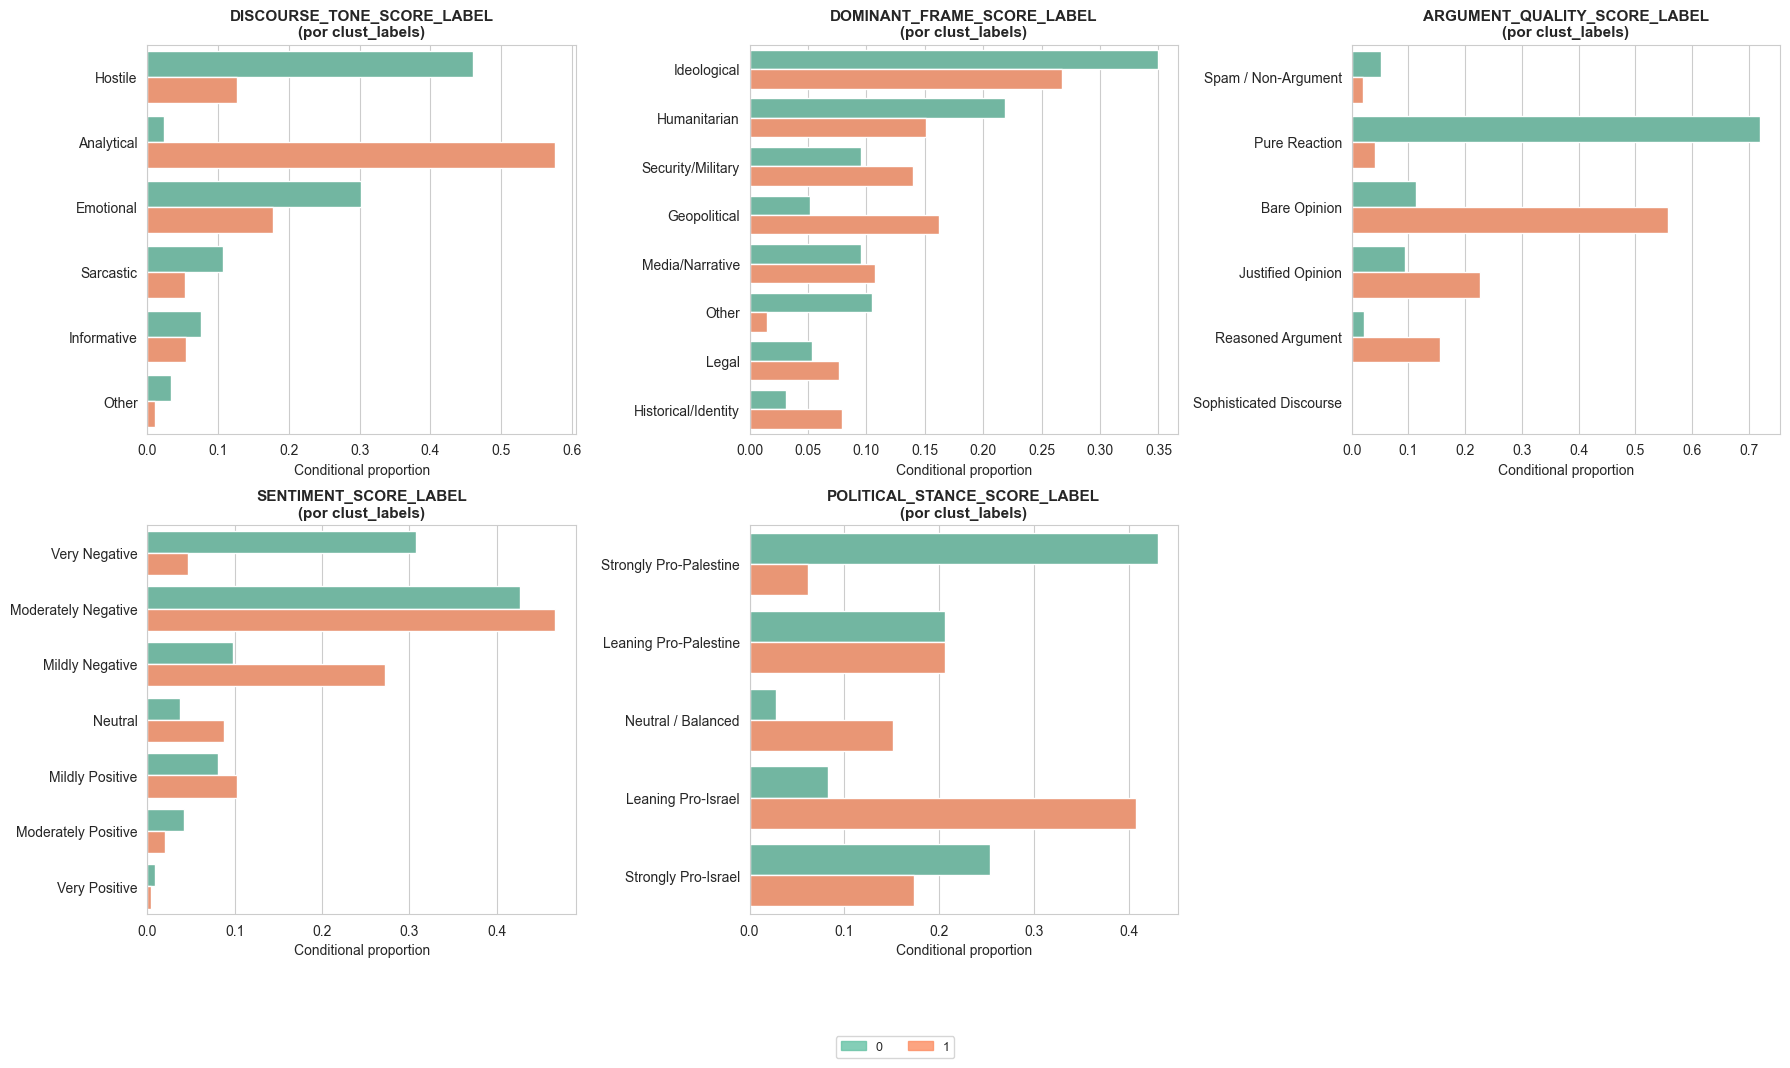

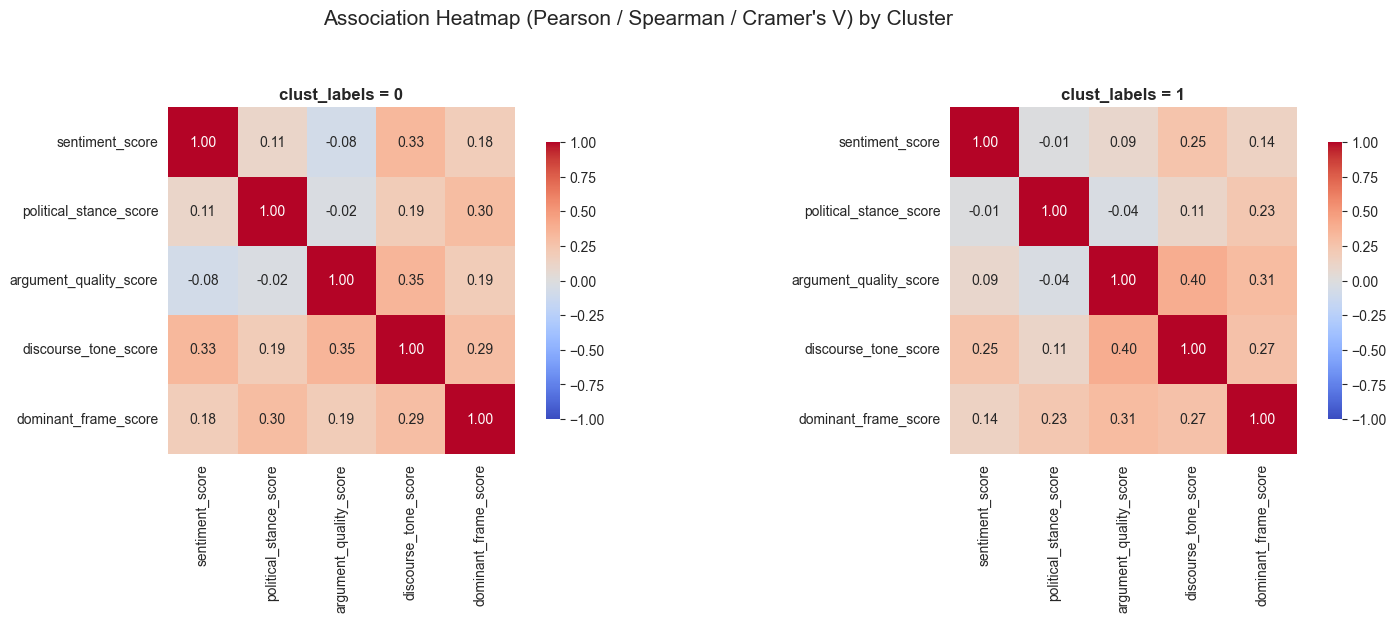

--------------------------------------------------
Medoid and KNN for Cluster 0:

--------------------------------------------------
shape: (11, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ post_title ┆ post_body  ┆ comment_bo ┆ discourse ┆ dominant_ ┆ argument_ ┆ sentiment ┆ political │
│ ---        ┆ ---        ┆ dy         ┆ _tone_sco ┆ frame_sco ┆ quality_s ┆ _score_la ┆ _stance_s │
│ str        ┆ str        ┆ ---        ┆ re_label  ┆ re_label  ┆ core_labe ┆ bel       ┆ core_labe │
│            ┆            ┆ str        ┆ ---       ┆ ---       ┆ l         ┆ ---       ┆ l         │
│            ┆            ┆            ┆ str       ┆ str       ┆ ---       ┆ str       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ str       ┆           ┆ str       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Life       ┆ After an   ┆ There is   ┆ Hos

KeyboardInterrupt: 

In [11]:
for n_clusters in N_CLUSTERS_LIST:

    get_SampleDistClustering_results(
        n_clusters, processed_data[:1000], quant_cols, binary_cols, multiclass_cols, 
        QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
    )

# Time: 60 mins

## Clustering III: Data - Embeddings (PCA 50% explained variance)

In [21]:
X[:,:10]

embedding_pca50_001,embedding_pca50_002,embedding_pca50_003,embedding_pca50_004,embedding_pca50_005,embedding_pca50_006,embedding_pca50_007,embedding_pca50_008,embedding_pca50_009,embedding_pca50_010
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.213251,-0.062078,0.350947,-0.01937,-0.029104,-0.067713,-0.021223,0.060825,0.090766,-0.055979
0.288731,0.174385,-0.064011,-0.039234,-0.143453,-0.104599,-0.004273,-0.010207,-0.05904,-0.043934
0.020834,-0.373226,-0.184872,-0.005644,0.030357,0.093148,-0.093401,0.019502,0.030393,0.091681
0.306588,0.158197,-0.086913,-0.115894,0.037009,0.122014,-0.008289,-0.056219,0.012091,0.025446
-0.363306,0.078169,0.005834,-0.190513,-0.107353,0.049026,0.048507,0.022908,0.08508,0.000224
…,…,…,…,…,…,…,…,…,…
-0.079497,-0.232624,0.094294,-0.005316,-0.248946,0.071179,0.10291,-0.118505,-0.032795,0.015848
0.04609,-0.259099,0.17899,0.013639,0.005368,-0.122822,-0.150191,-0.072578,-0.020507,-0.009129
0.246584,-0.135442,0.111621,-0.170913,0.259243,0.069082,0.138617,-0.042631,0.082097,-0.045177


KMeans - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


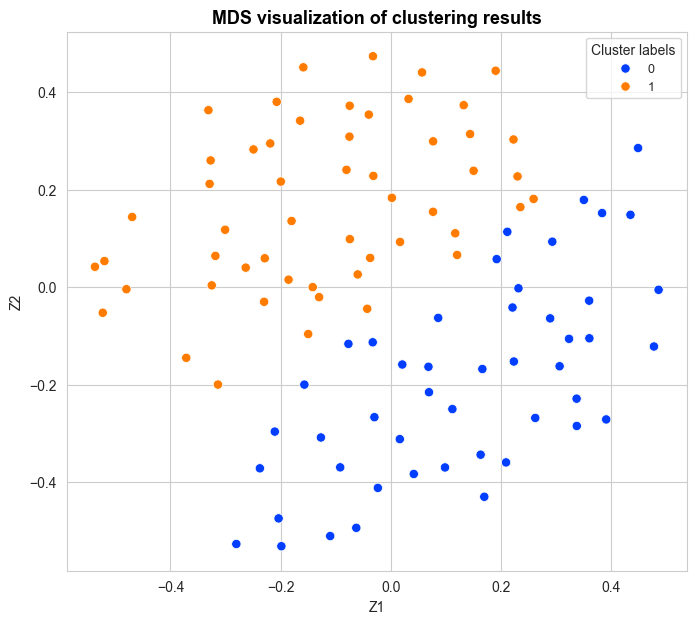

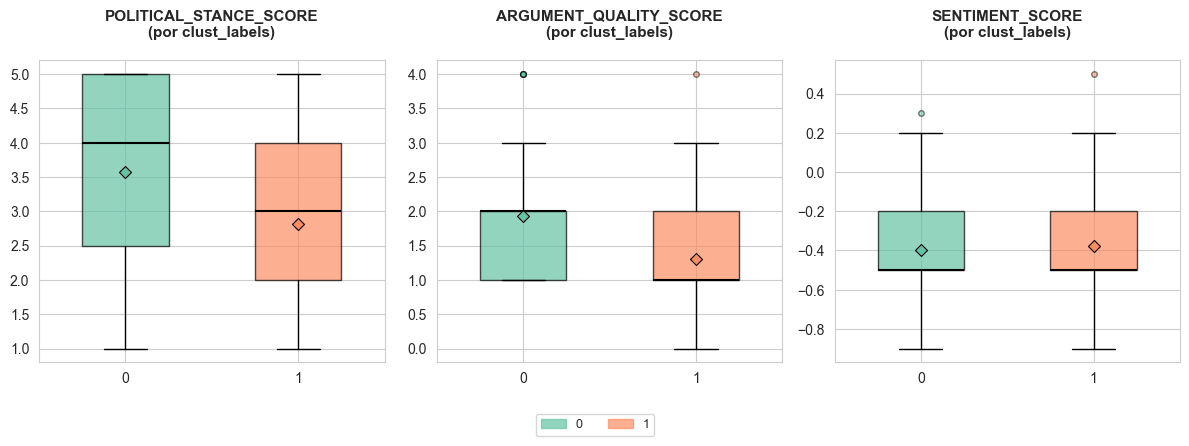

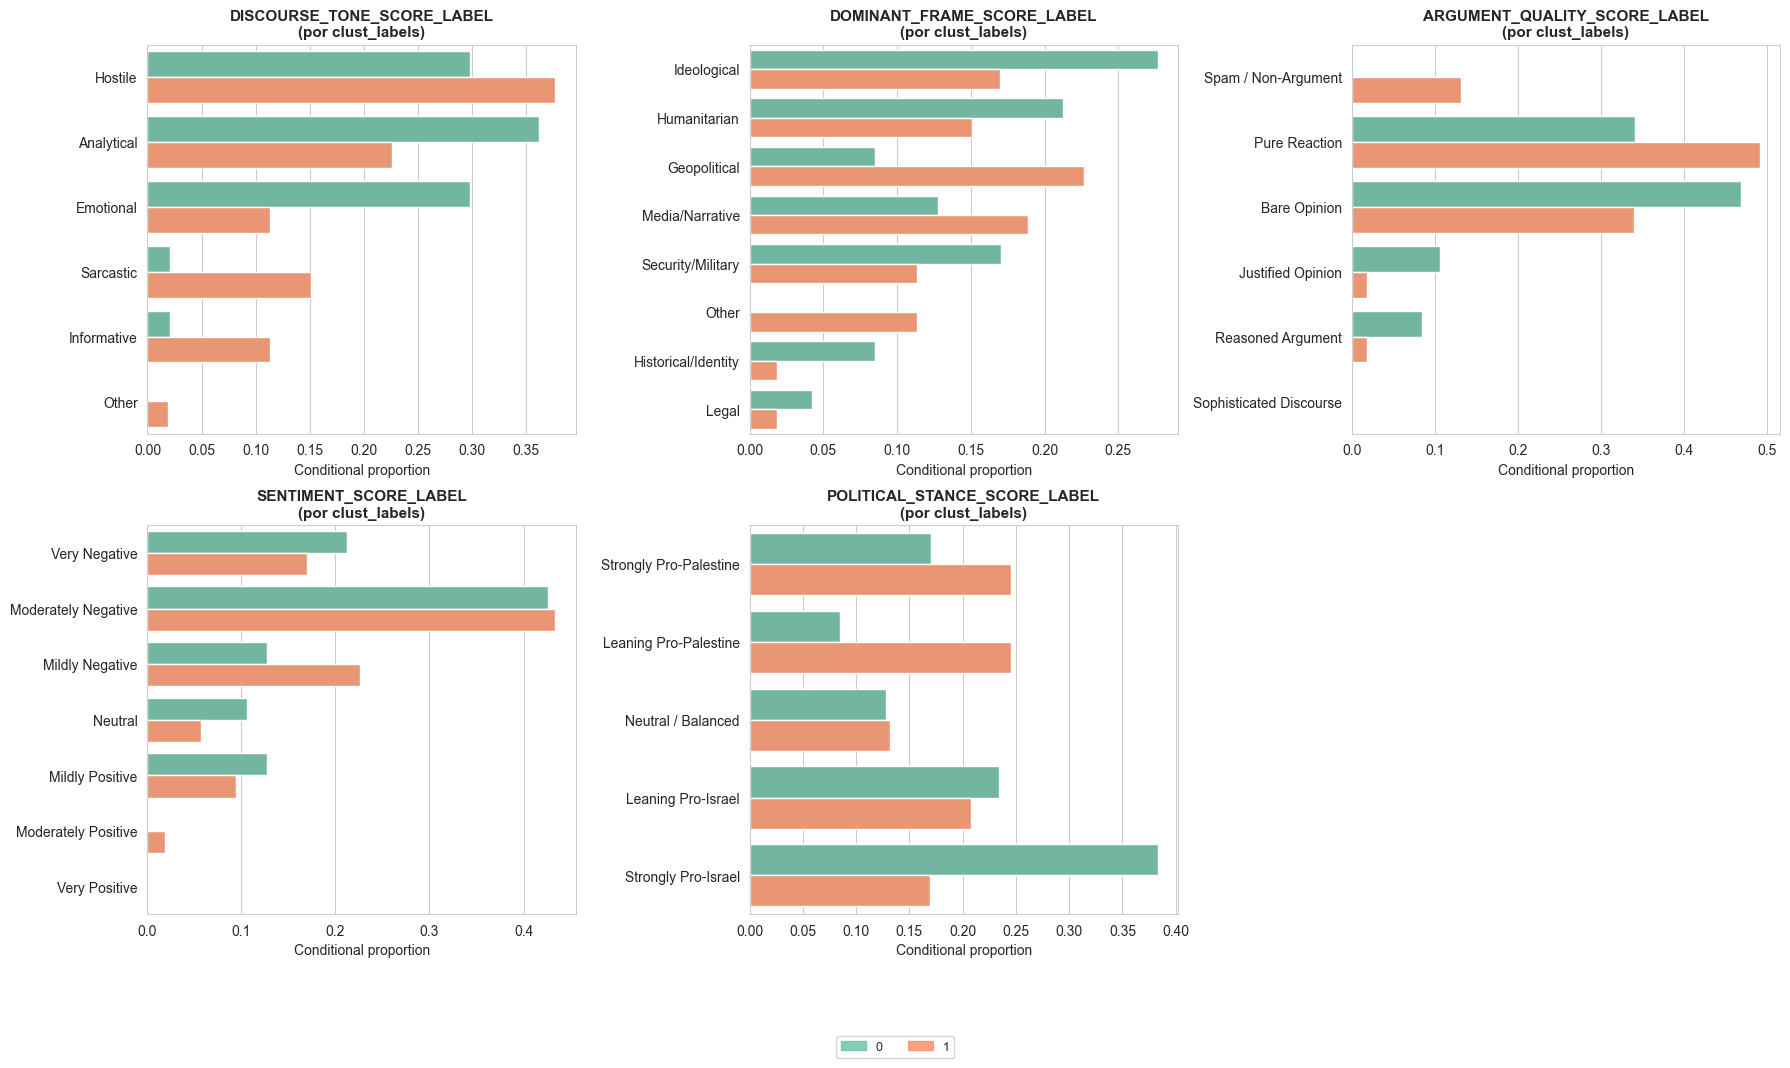

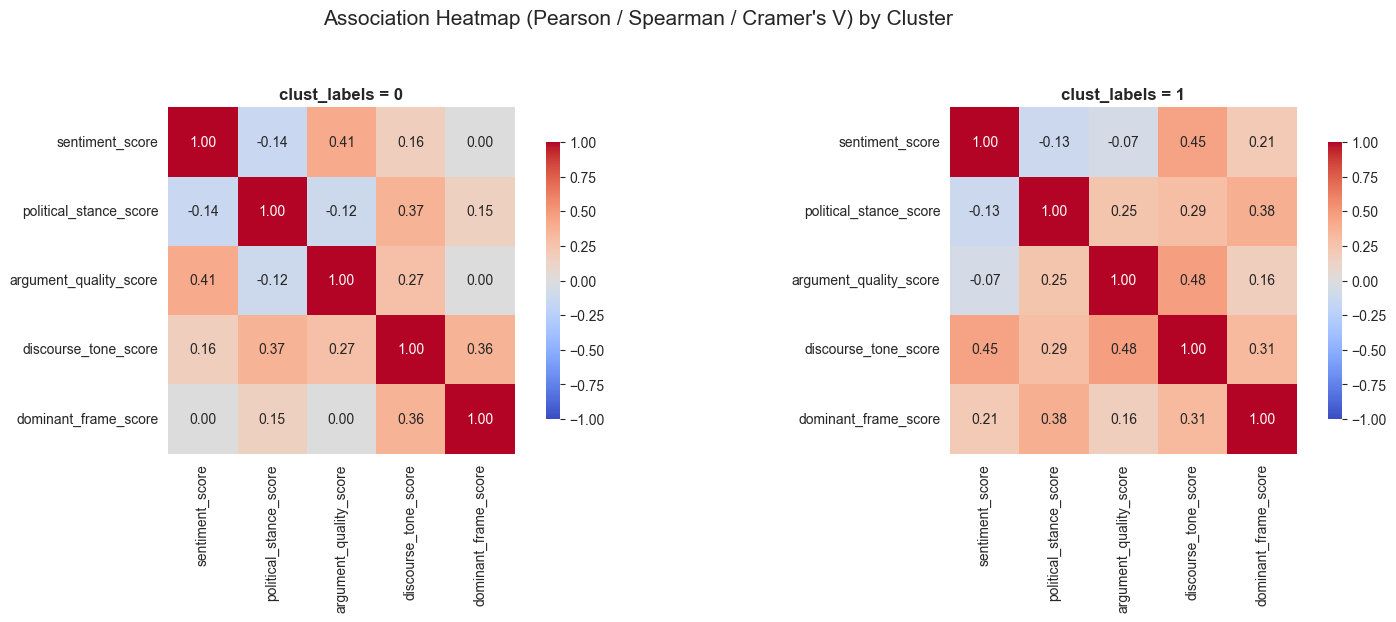

KMeans - k=3


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


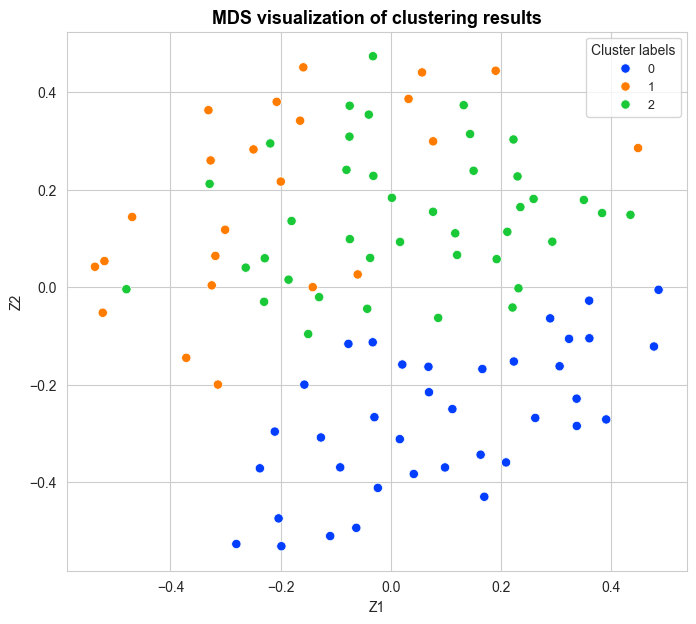

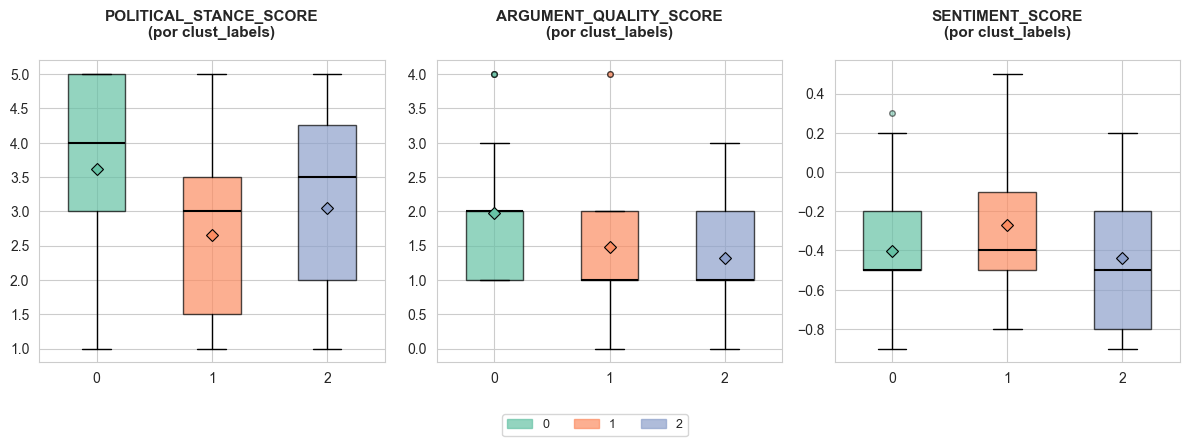

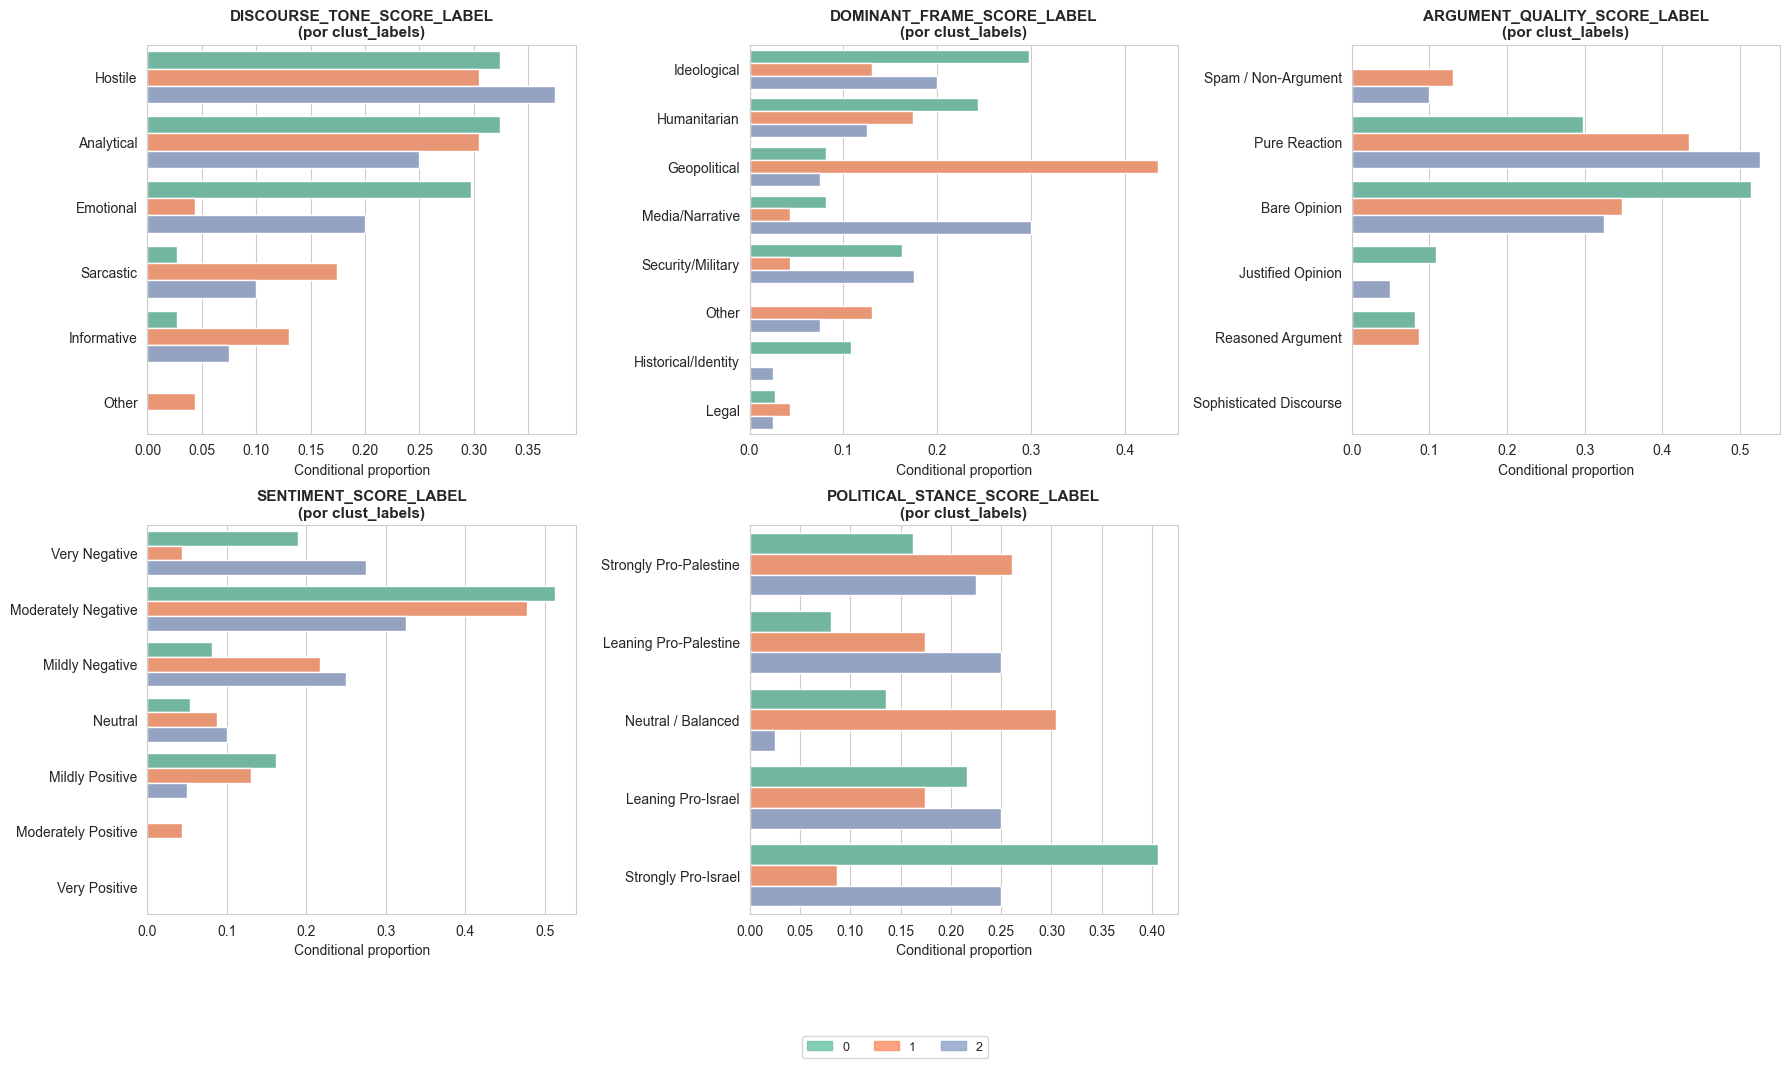

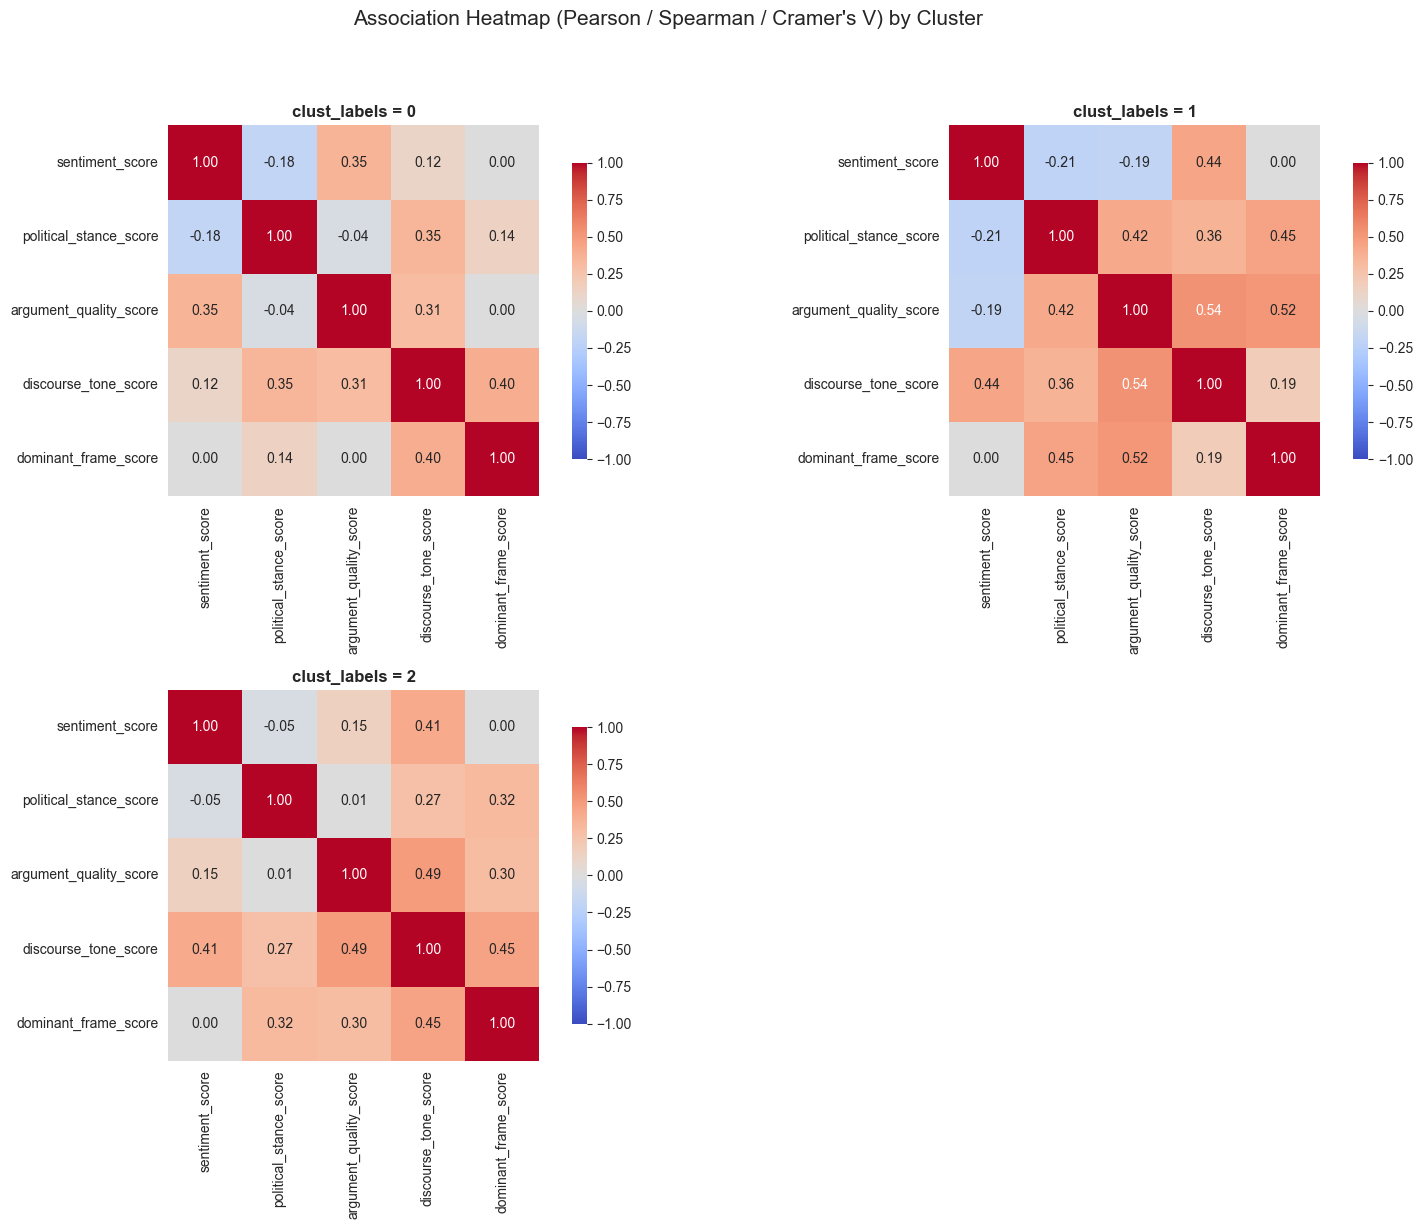

KMeans - k=4


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


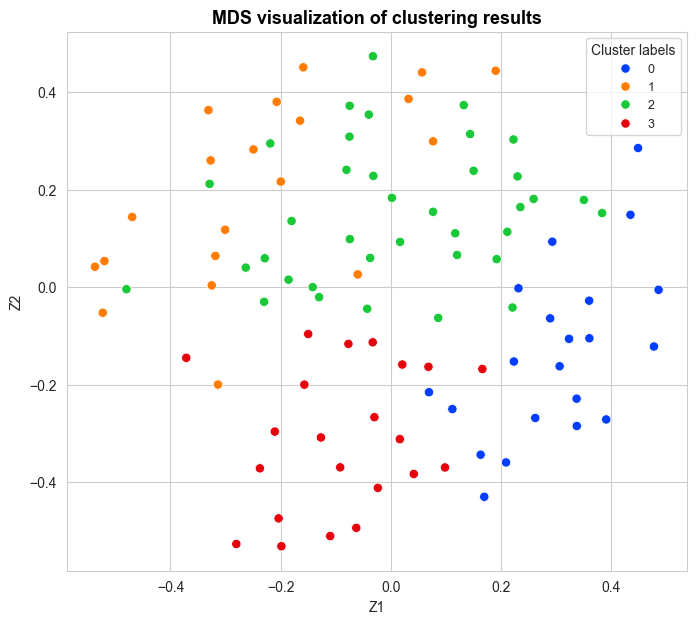

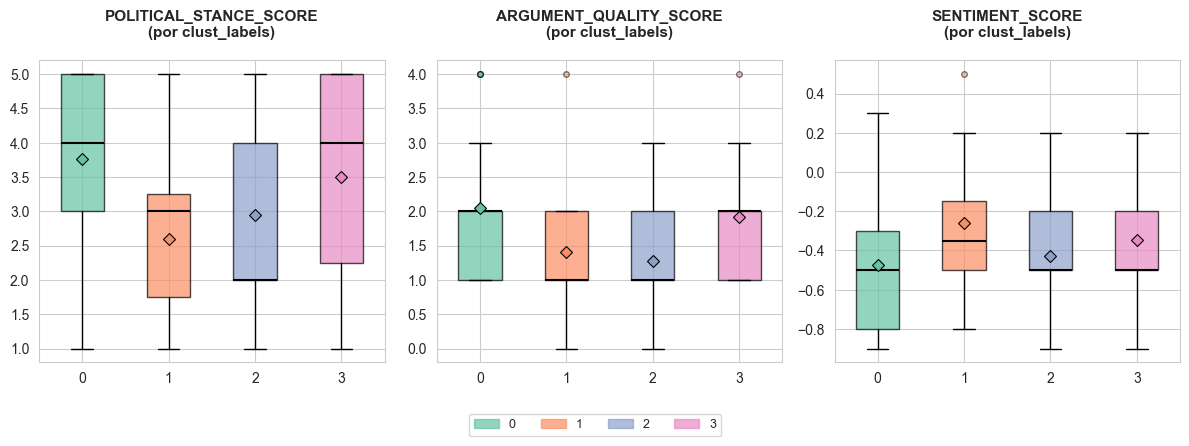

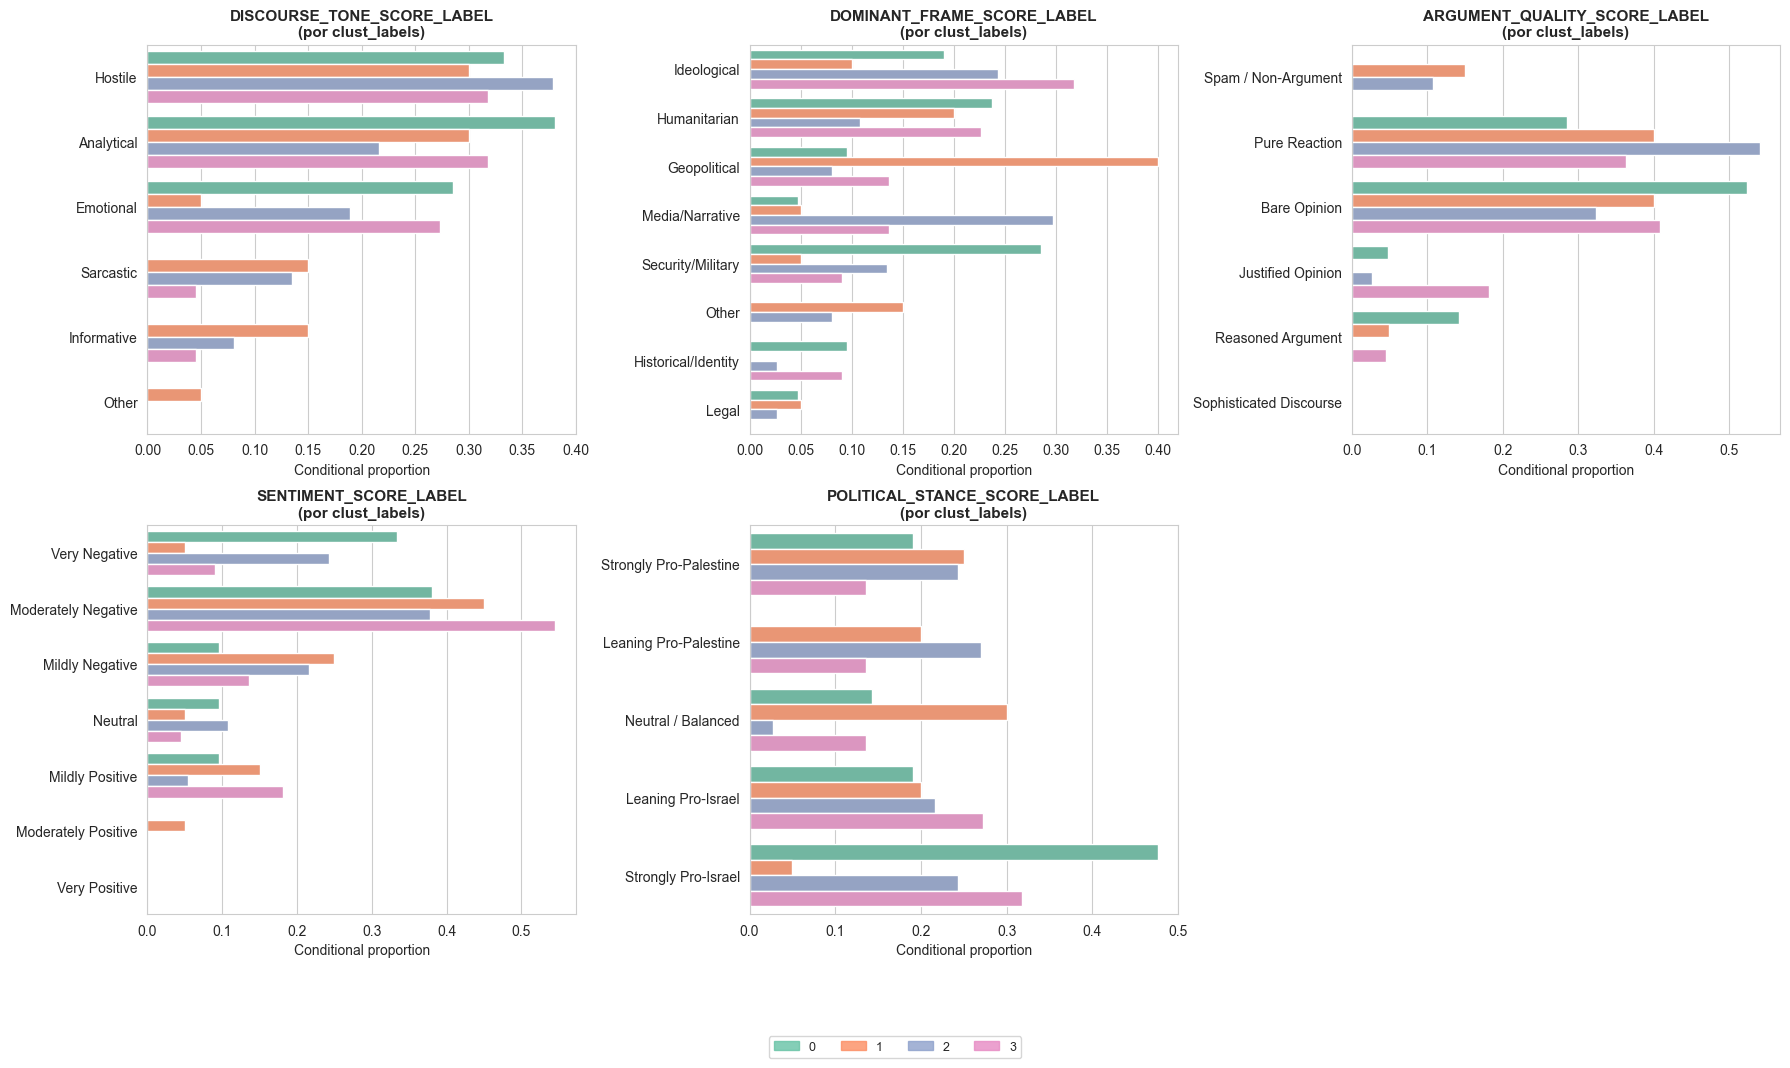

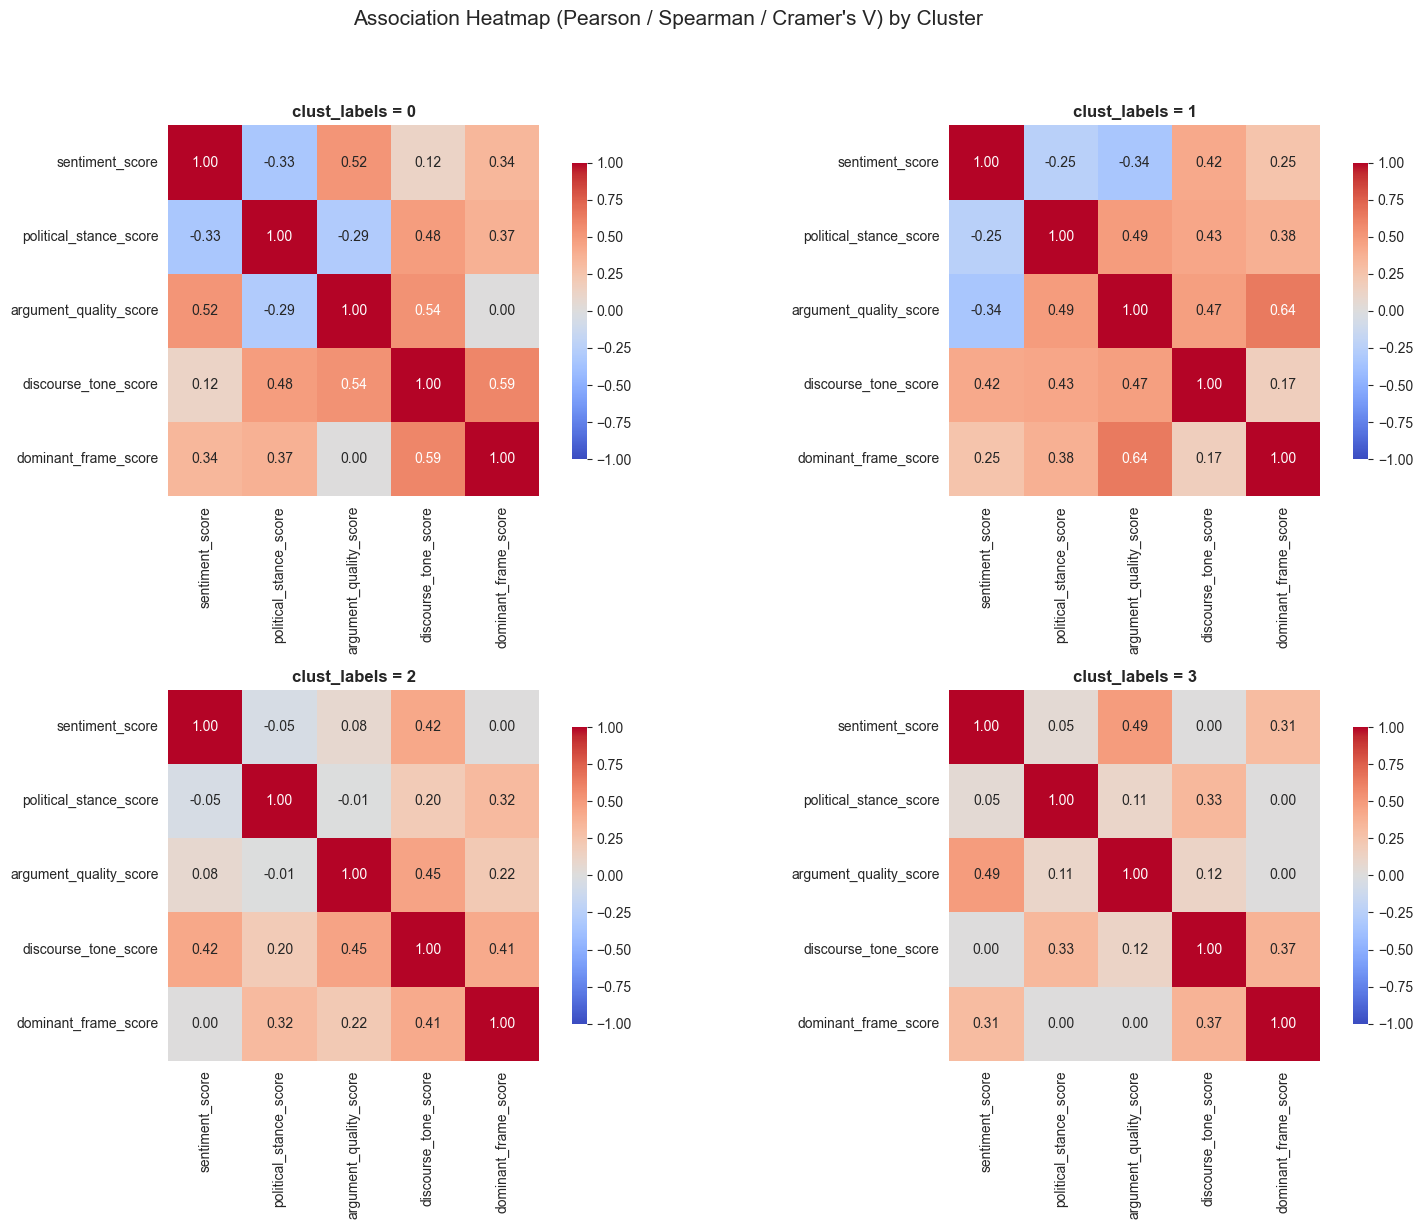

KMeans - k=5


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


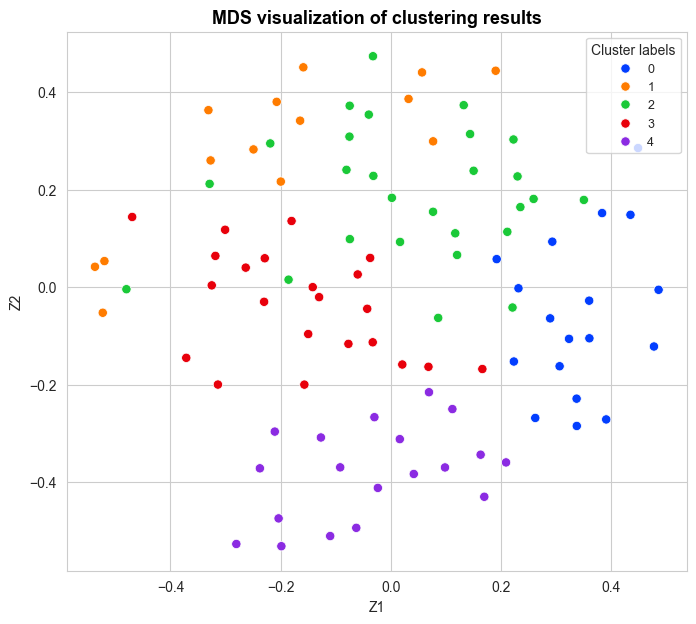

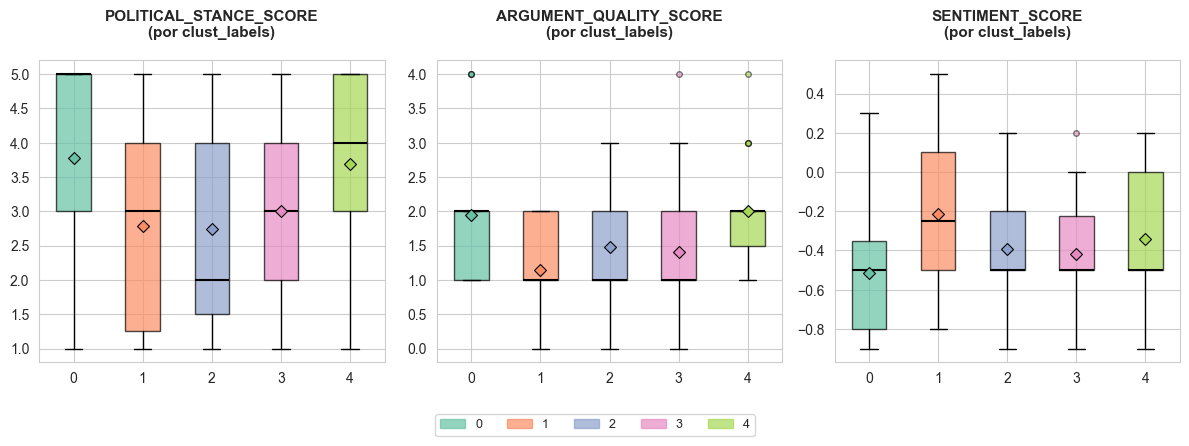

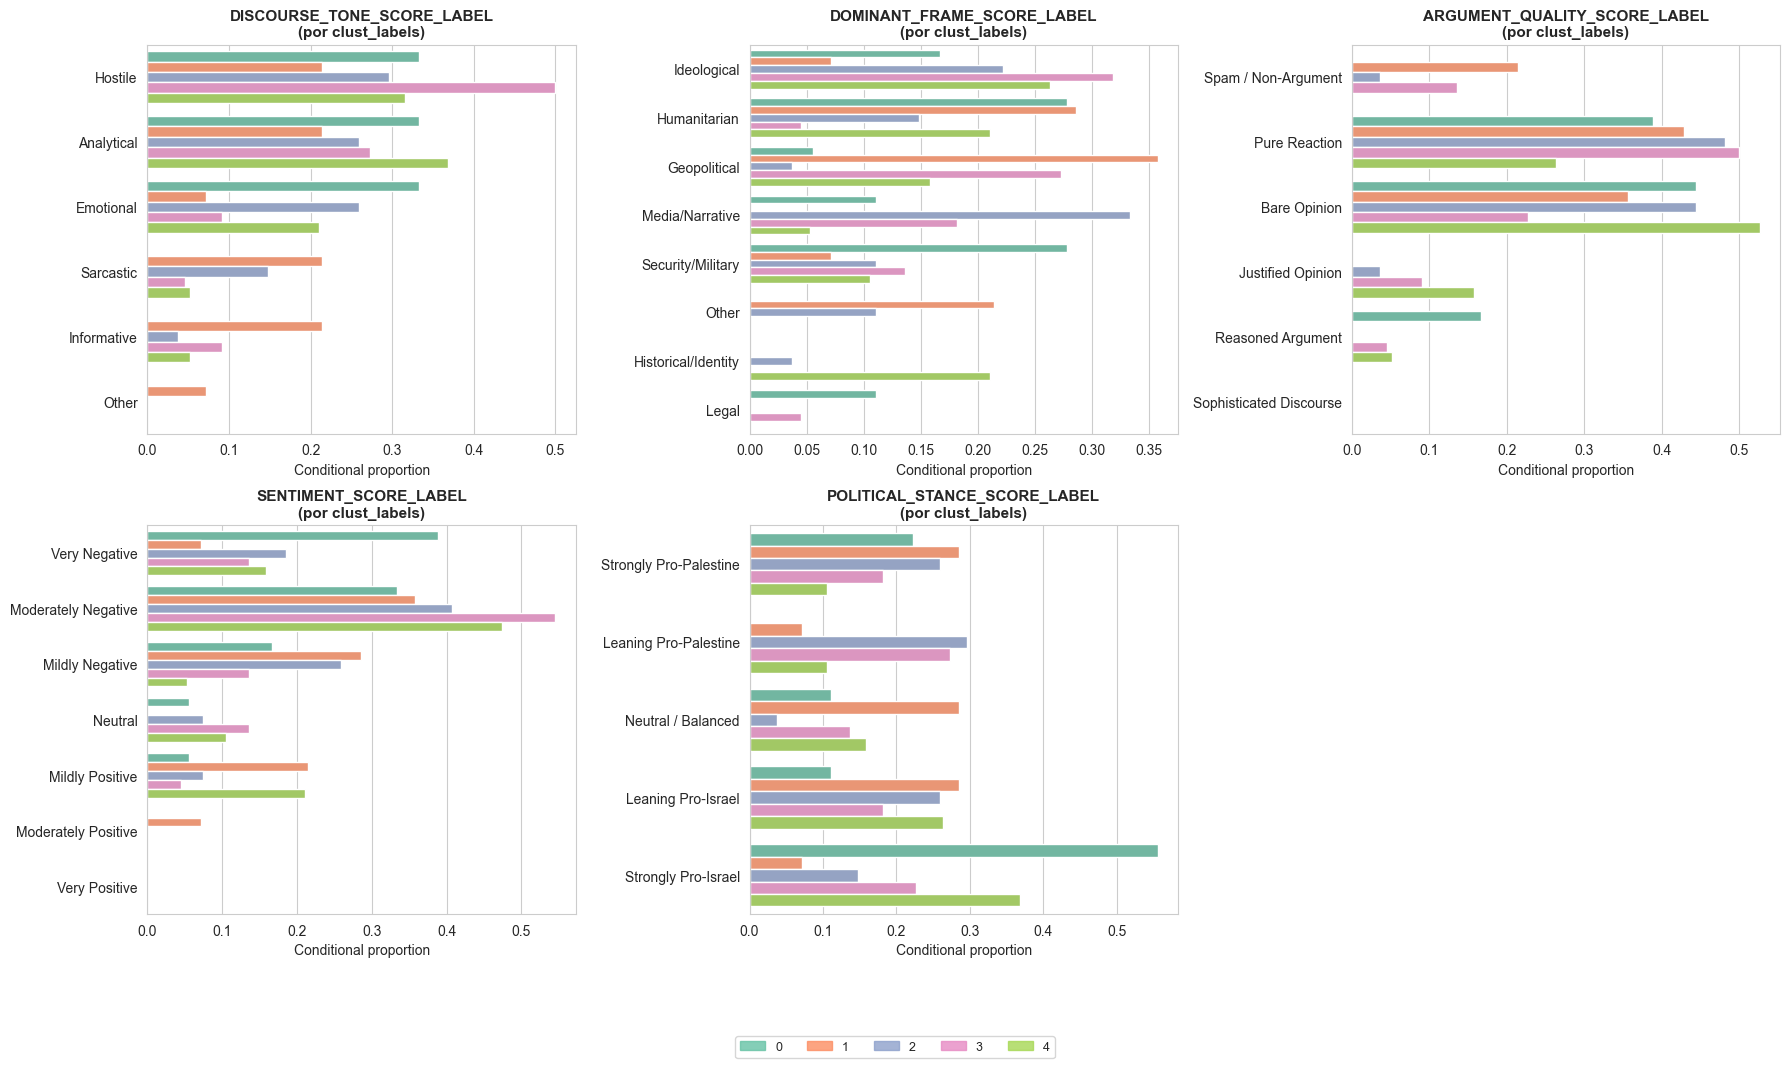

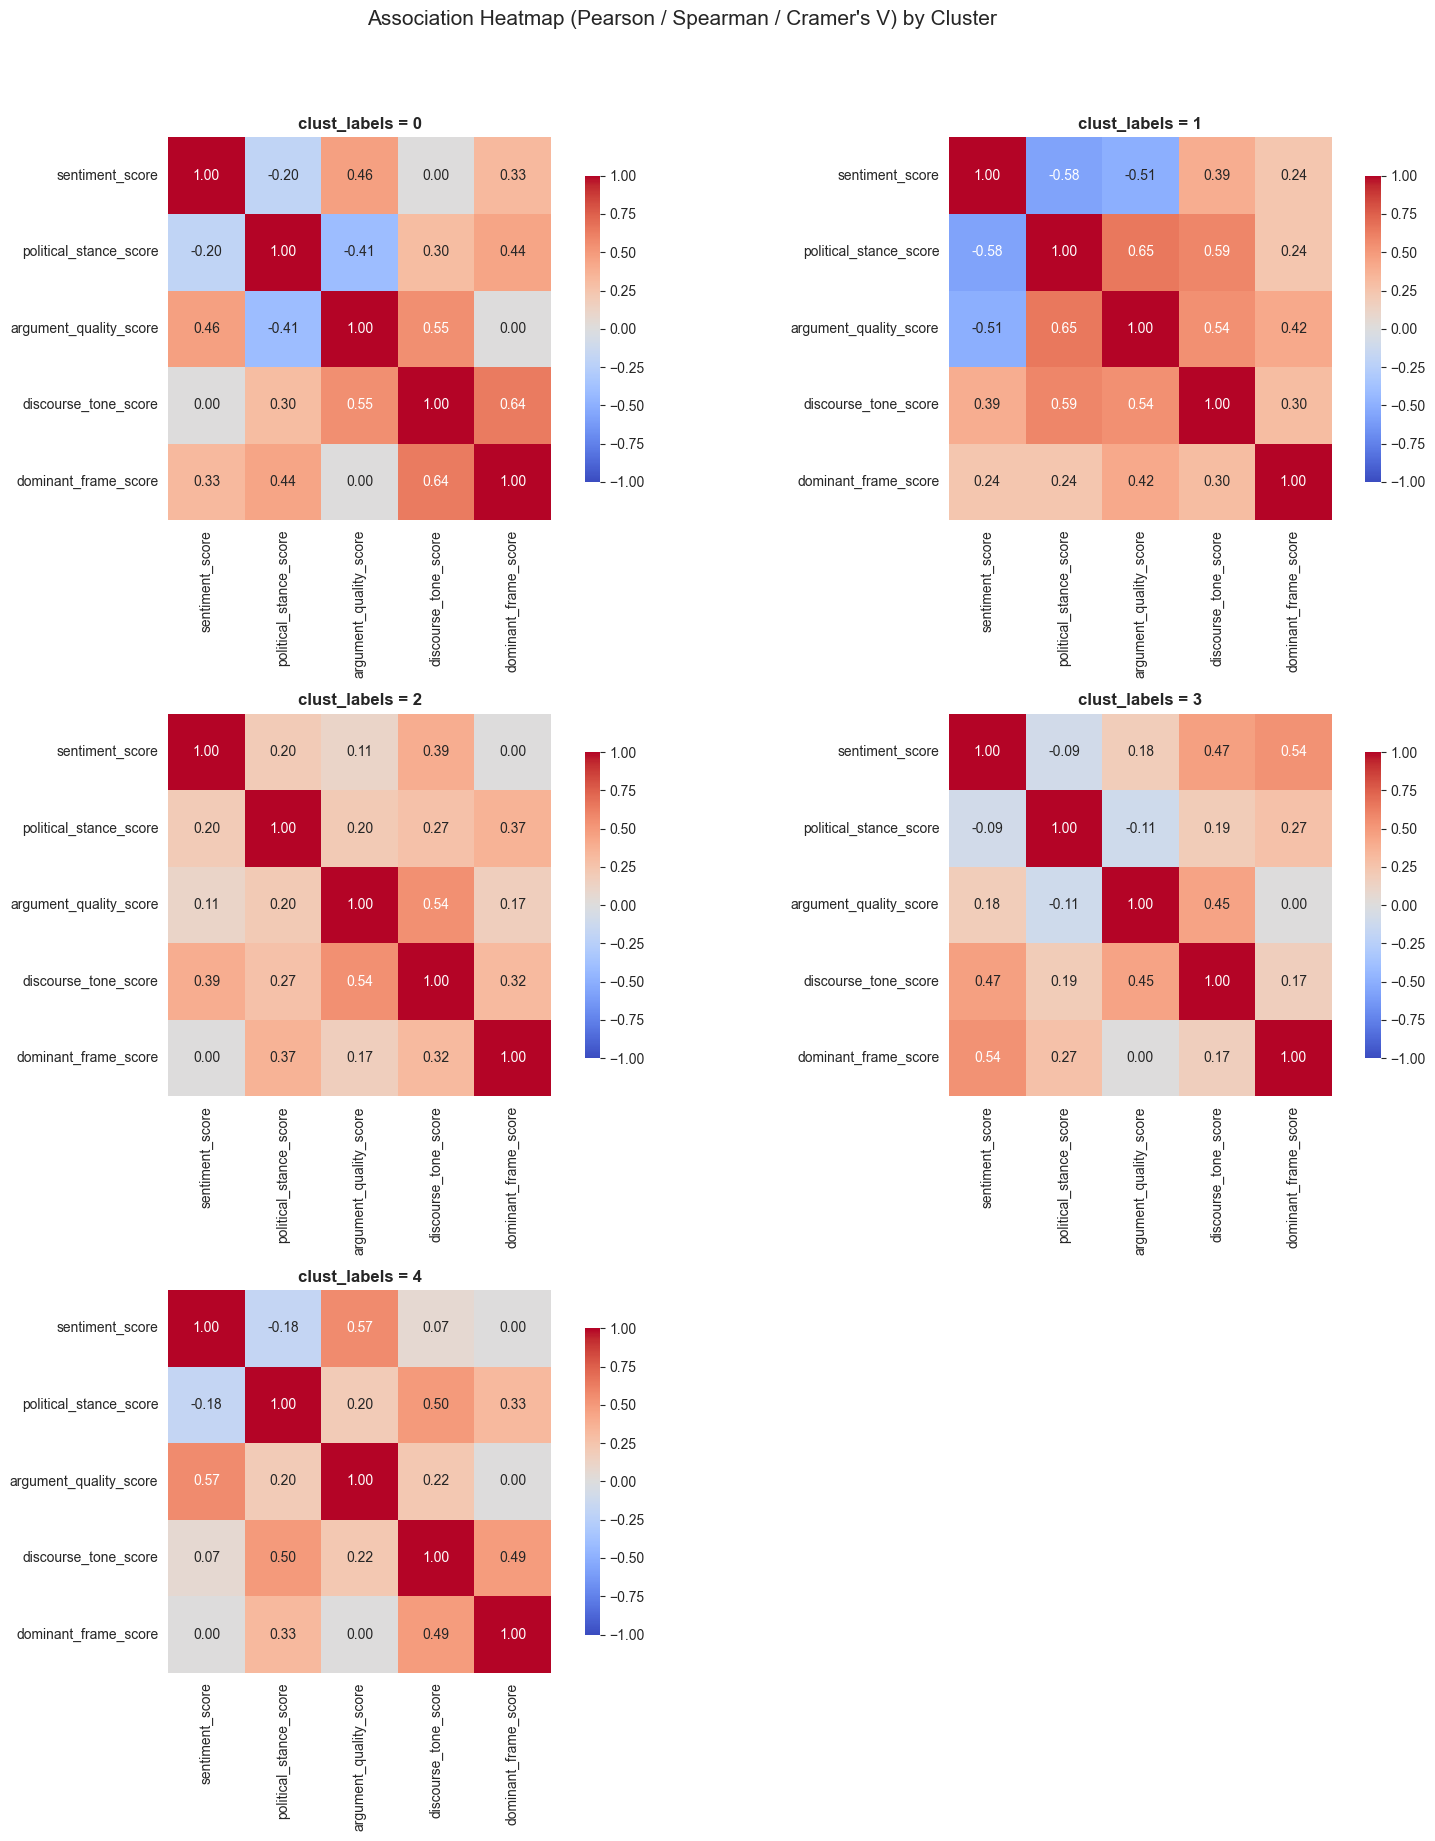

In [25]:
X = processed_data[embeddings_cols_50]

for n_clusters in N_CLUSTERS_LIST:

    get_KMeans_results(
        n_clusters, processed_data[:100], X[:100,:10], QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
        )

# Time: 10 mins

## Clustering III-b: Data - Embeddings (PCA 90% explained variance)

KMeans - k=2


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


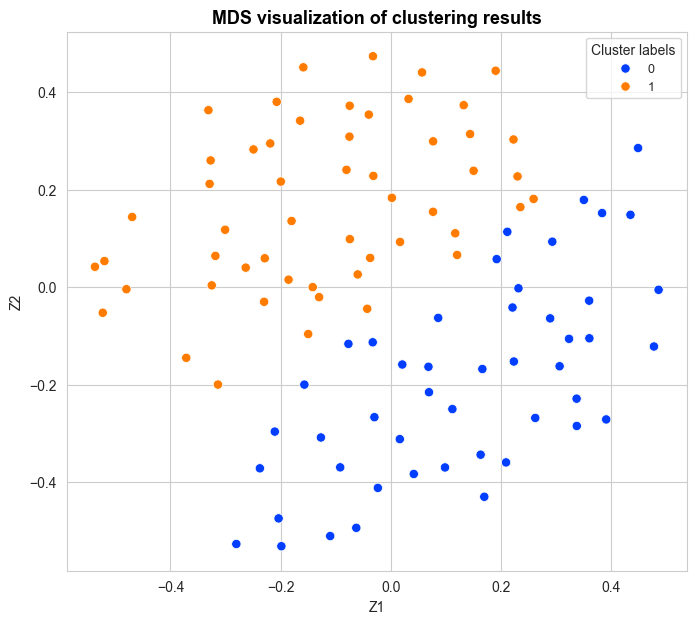

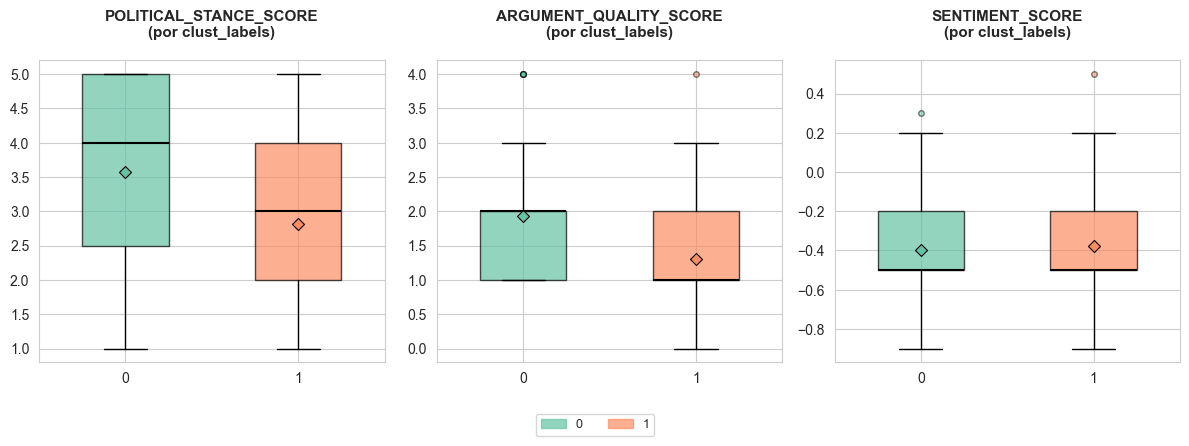

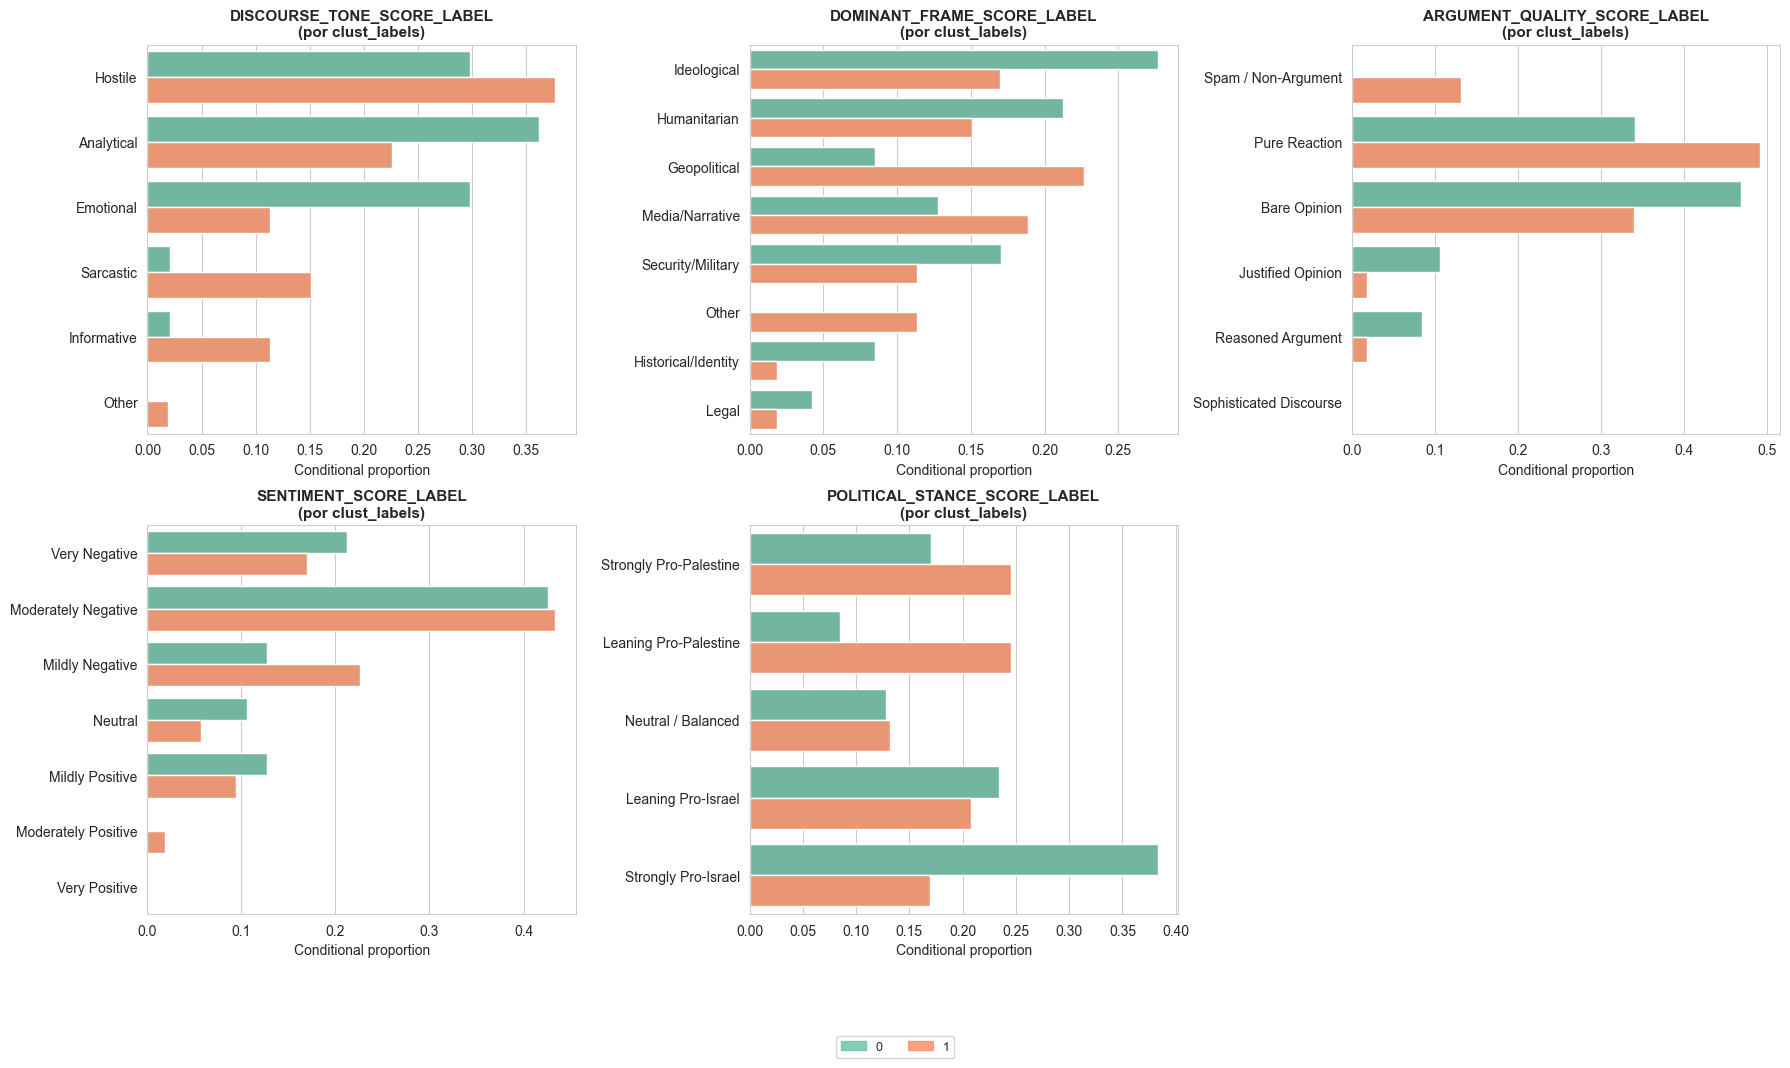

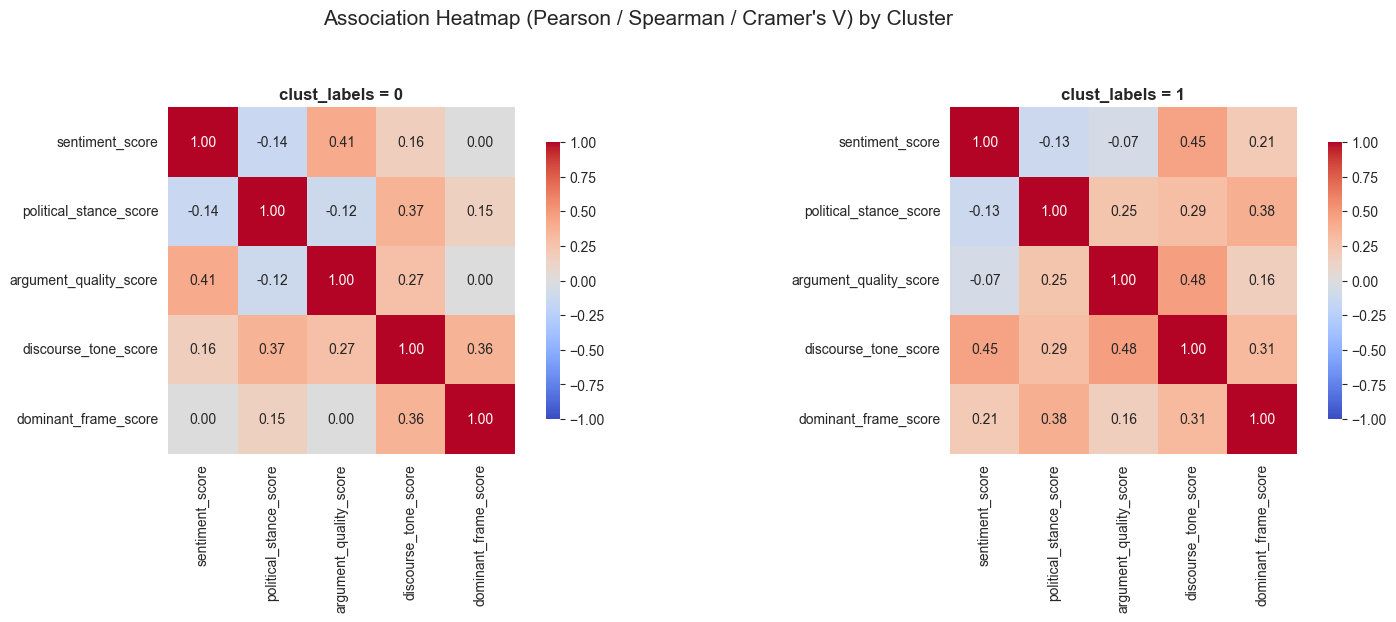

KMeans - k=3


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


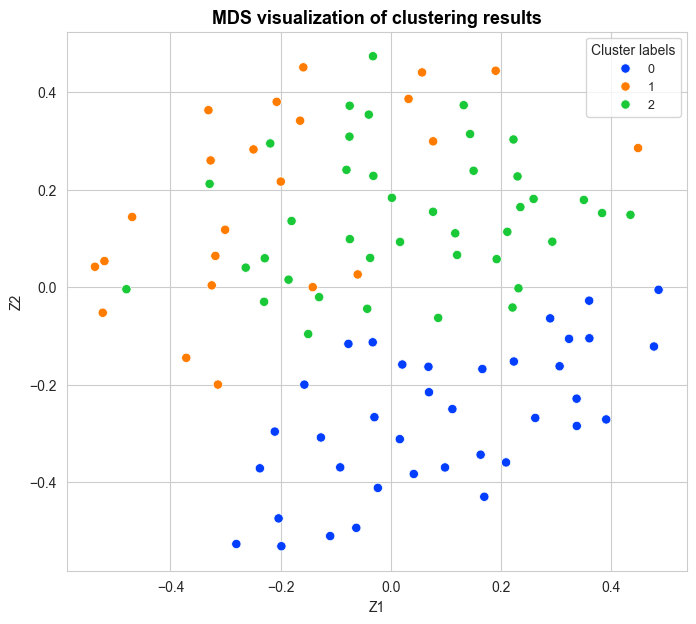

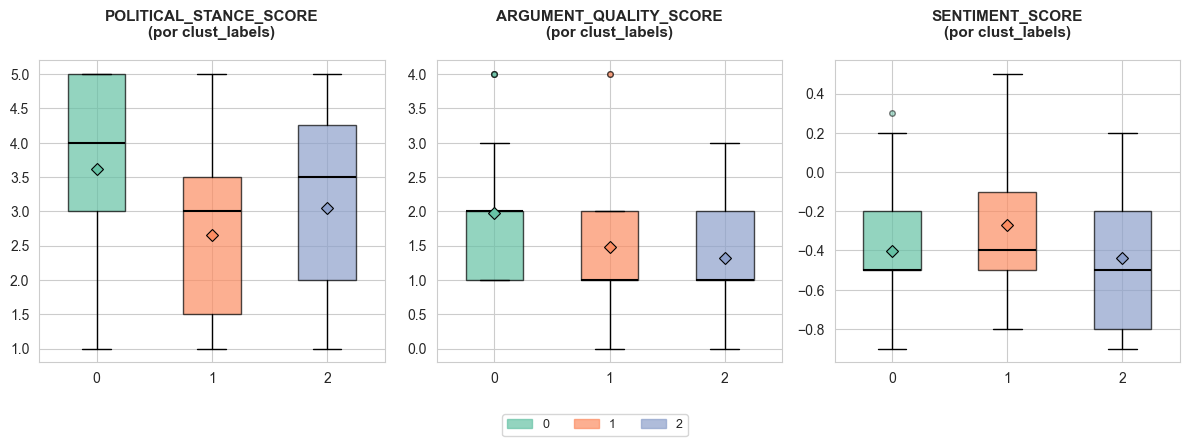

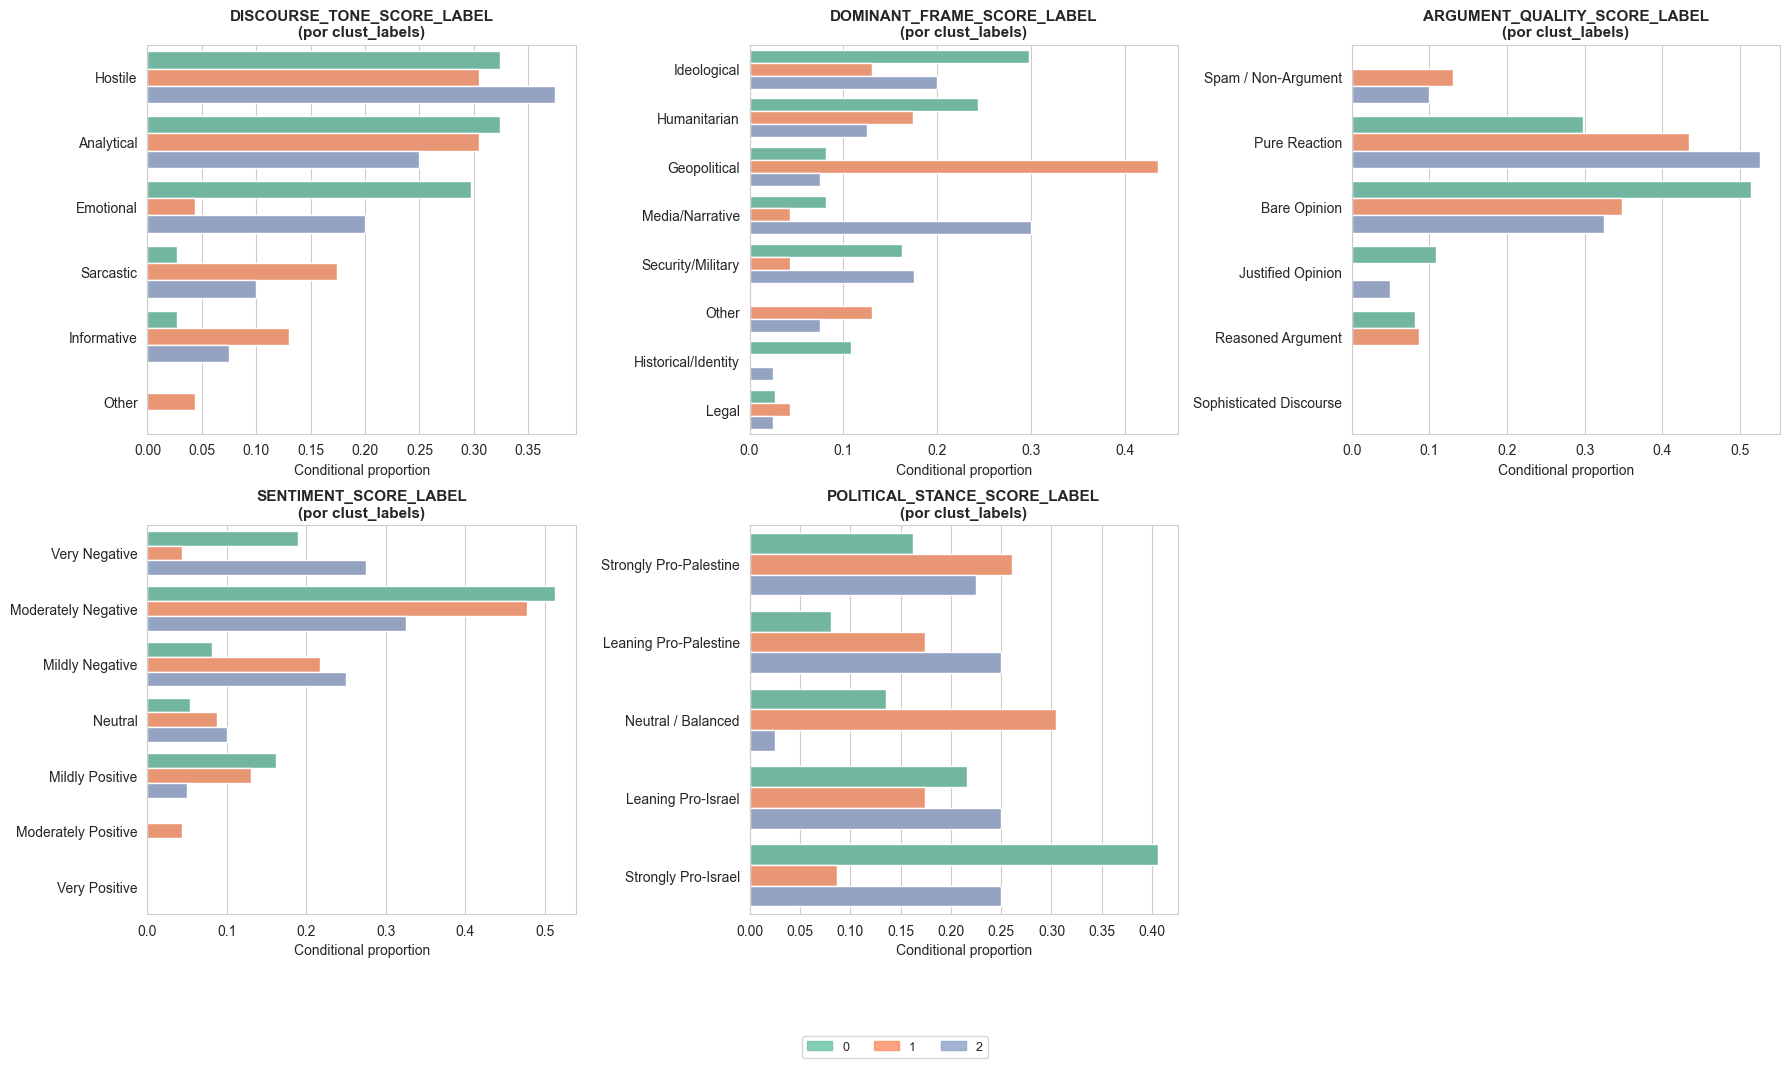

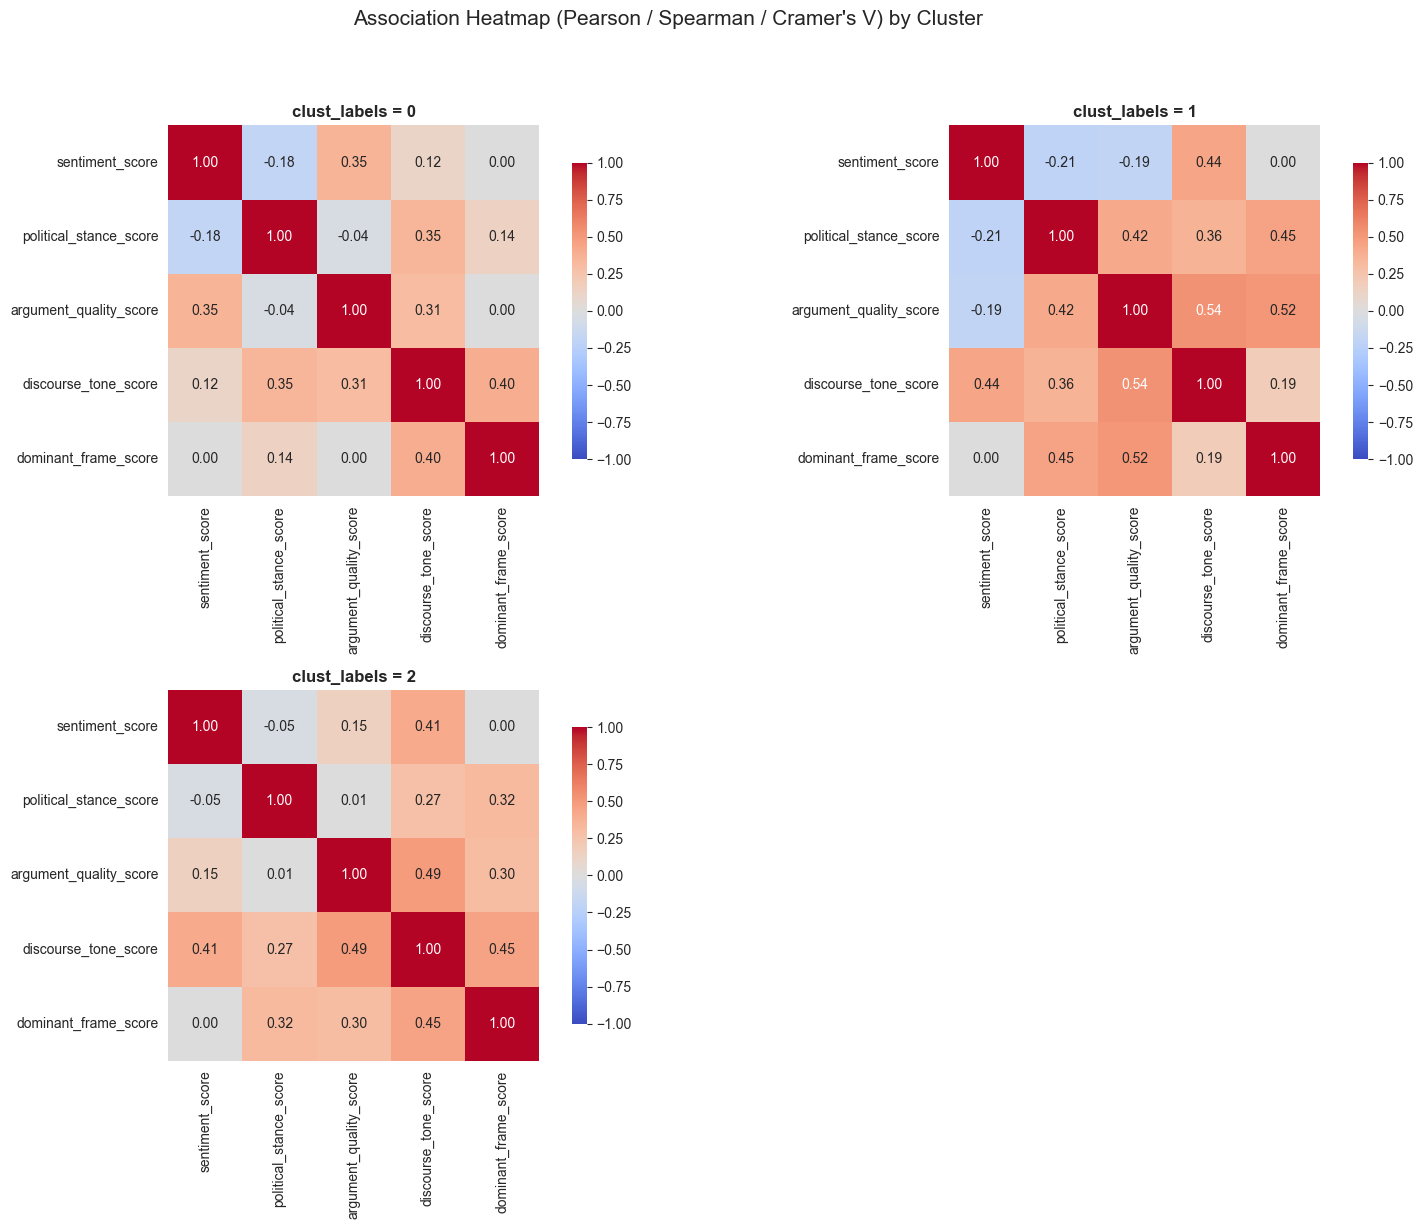

KMeans - k=4


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


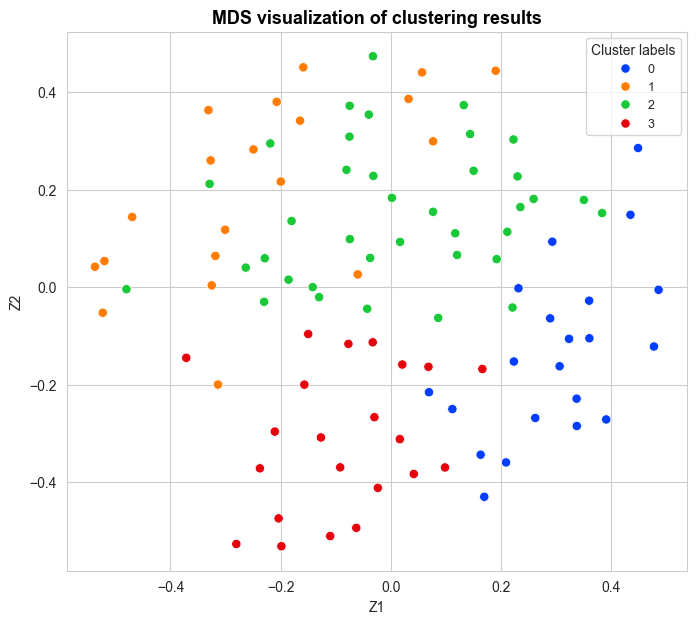

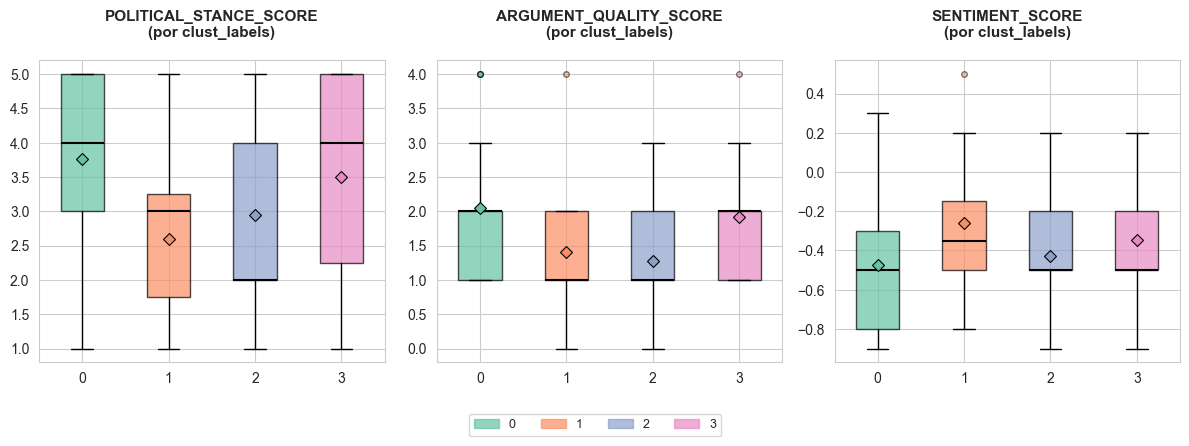

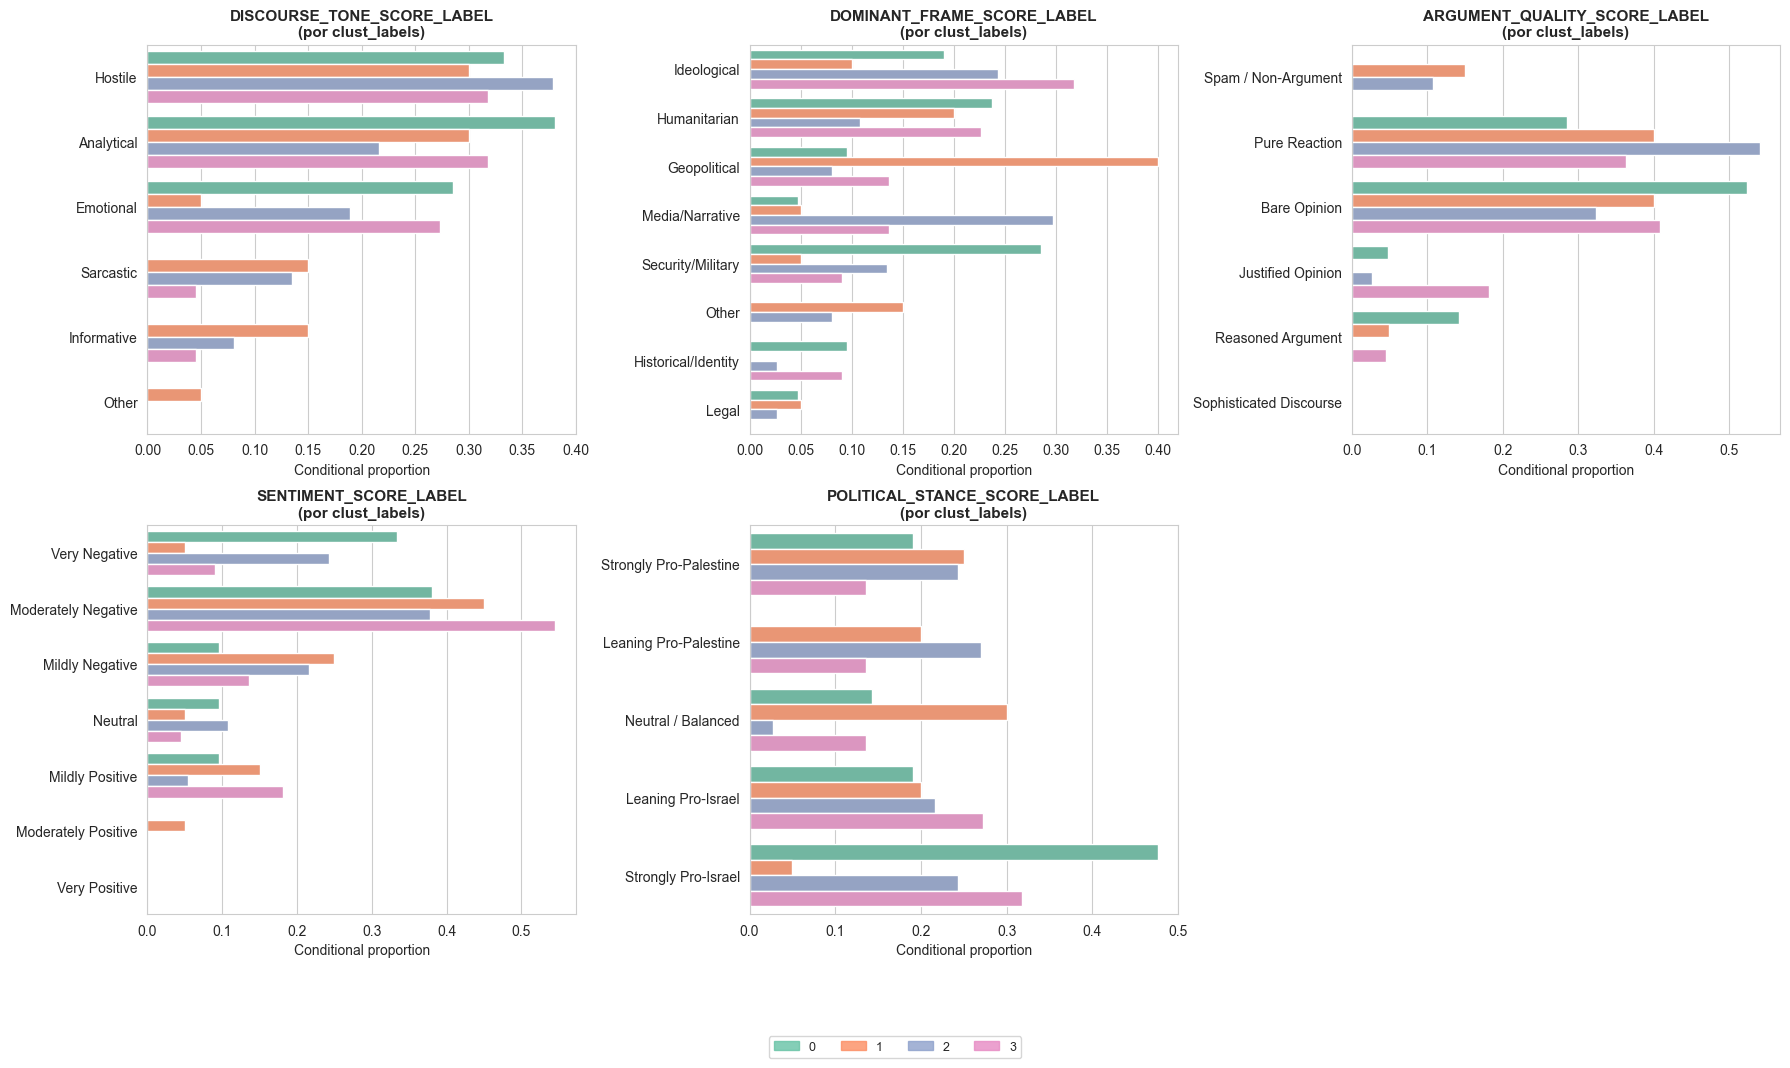

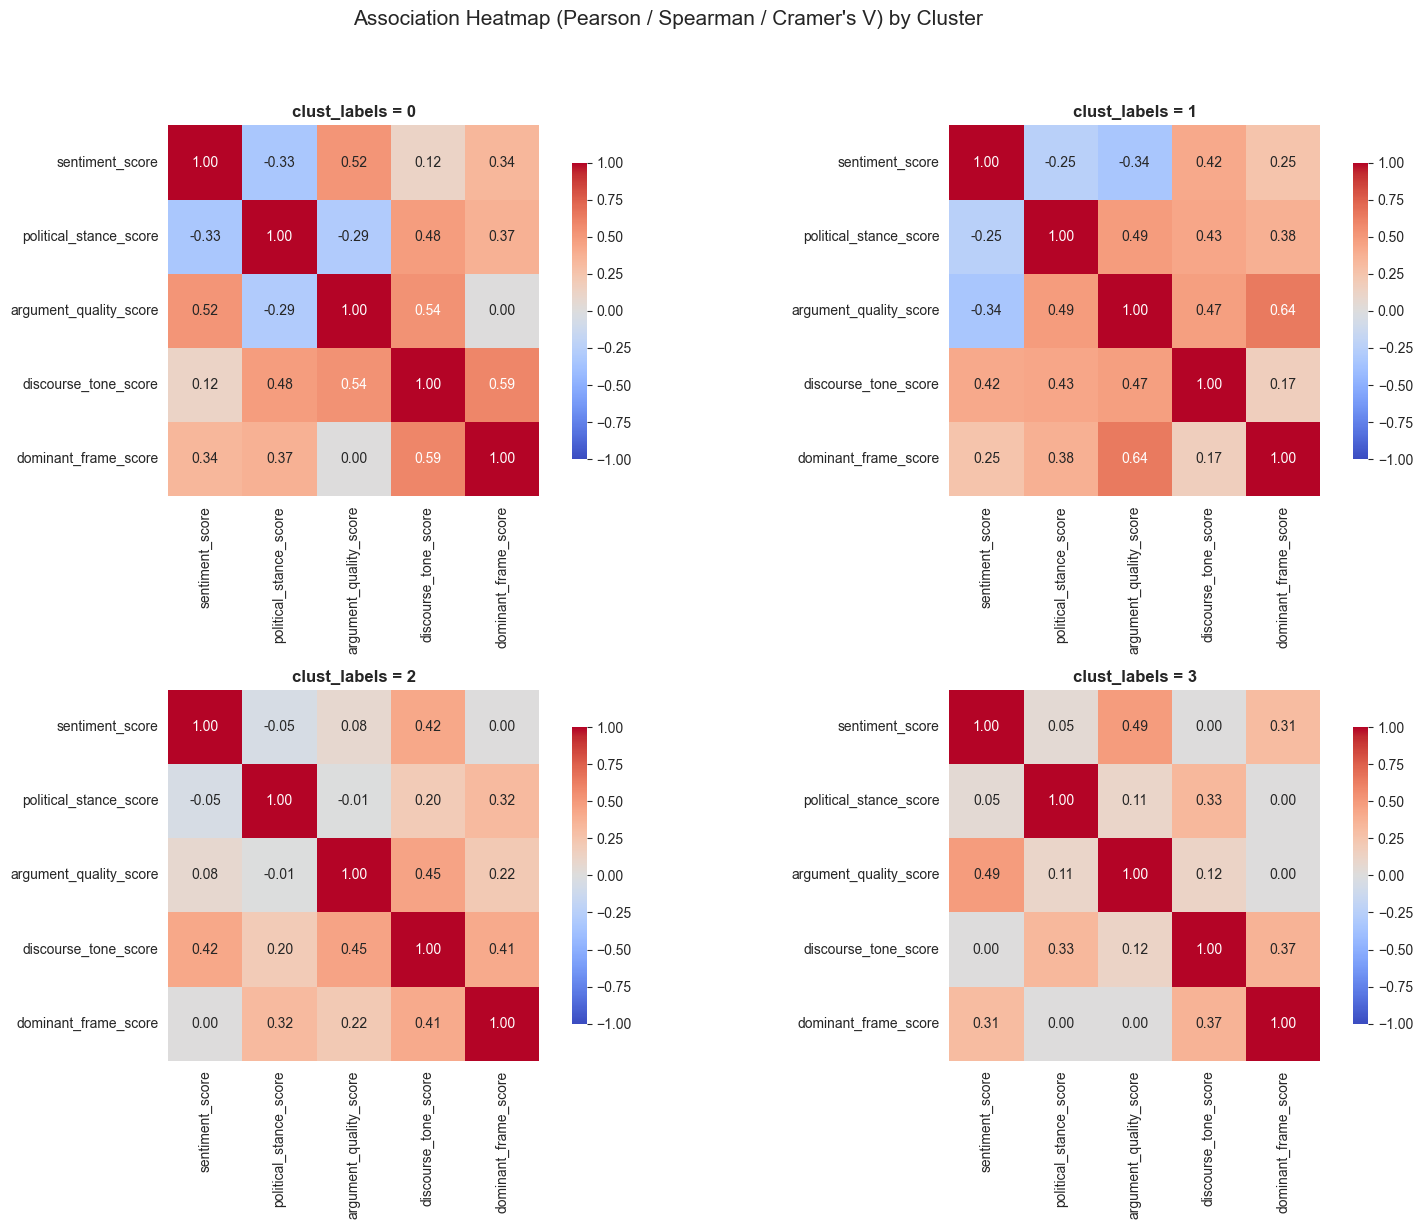

KMeans - k=5


c:\Users\fscielzo\Documents\PhD\paper-4\paper-code\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


KeyboardInterrupt: 

In [26]:
X = processed_data[embeddings_cols_90]

for n_clusters in N_CLUSTERS_LIST:

    get_KMeans_results(
        n_clusters, processed_data[:100], X[:100,:10], QUANT_COMPARISON_COLS, CAT_COMPARISON_COLS, CAT_COMPARISON_ORDER, ASSOCIATION_VAR_TYPES
        )

# Time: 10 mins